In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as cte

from scipy.optimize import newton
from pathlib import Path

MIDPOINT_FILE = "midpointTFRM.dat"
OBJECTS_FILE  = "ObjectsCatalogue.dat"
SATCAT_FILE   = "satcat (2).csv"

OUTPUT_ALL  = "detections_enriched_all_TFRM.csv"
OUTPUT_SNR3 = "detections_enriched_snr3_TFRM.csv"
OUTPUT_SNR6 = "detections_enriched_snr6_TFRM.csv"

In [5]:
# Telescope configuration TFRM

pixel_size = 9.0 * u.um
focal_length = 480 * u.mm      # f/1 amb D = 0.5 m
aperture_diameter = 500 * u.mm

exposure_time = 30 * u.s  #??
wavelength = 542.0 * u.nm

quantum_efficiency = 0.6  
readout_noise = 9 * u.electron 
dark_current = 0.07 * u.electron / u.s  

background_magnitude = 21.7
m_o = 1

# Zero-point flux
F_0 = 2.518021002e-8 * u.W / u.m**2


In [6]:
# Useful functions

def get_pixel_size_ang(pixel_size, focal_length):
    return (pixel_size / focal_length).decompose() * u.rad


def get_pixel_residence_time(pixel_ang_size, angular_velocity):
    return (pixel_ang_size / angular_velocity).decompose()


def get_flux_from_mag(mag):
    return F_0 * np.power(10, -mag / 2.5)


def get_electron_flux(flux_density, aperture, wavelength):
    return (flux_density * aperture * wavelength / cte.h / cte.c).decompose() * u.electron


def get_background_electron_flux(aperture, pixel_ang_size):
    F_bg = F_0 * np.power(10, -0.4 * background_magnitude) / u.arcsec**2
    return (F_bg * aperture * wavelength / cte.h / cte.c * pixel_ang_size**2).decompose() * u.electron


def get_snr(S_o, S_bg, S_d, S_r, Q_e, m_o, tau, t_exp):
    return S_o * Q_e * tau / np.sqrt(
        S_r
        + S_o / m_o * Q_e * tau
        + (S_bg * Q_e + S_d) * t_exp
    )

In [7]:
# Pre-computed telescope values

aperture = np.pi * aperture_diameter**2 / 4
pixel_ang_size = get_pixel_size_ang(pixel_size, focal_length) * np.sqrt(2)

background_flux = get_background_electron_flux(aperture, pixel_ang_size)

print(f"Pixel angular size: {pixel_ang_size.to(u.arcsec):.3f}")
print(f"Aperture: {aperture.to(u.cm**2):.3f}")
print(f"Background flux: {background_flux:.3e}")

Pixel angular size: 5.469 arcsec
Aperture: 1963.495 cm2
Background flux: 8.431e+02 electron / s


In [8]:
def snr_for_magnitude(magnitude, angular_velocity):
    flux = get_flux_from_mag(magnitude)
    source_flux = get_electron_flux(flux, aperture, wavelength)

    tau = get_pixel_residence_time(pixel_ang_size, angular_velocity)
    tau = min(tau, exposure_time)

    snr = get_snr(
        source_flux,
        background_flux,
        dark_current,
        readout_noise,
        quantum_efficiency,
        m_o,
        tau,
        exposure_time
    )

    return snr.value

In [9]:
from scipy.optimize import brentq

def find_magnitude_for_snr(target_snr, angular_velocity):
    
    def root_func(magnitude):
        flux = get_flux_from_mag(magnitude)
        source_flux = get_electron_flux(flux, aperture, wavelength)

        tau = get_pixel_residence_time(pixel_ang_size, angular_velocity)
        tau = min(tau, exposure_time)

        snr = get_snr(
            source_flux,
            background_flux,
            dark_current,
            readout_noise,
            quantum_efficiency,
            m_o,
            tau,
            exposure_time
        ).value

        return snr - target_snr

    return brentq(root_func, -5, 25)

def compute_snr_curve(target_snr):
    mag_grid = []

    for w in omega_grid:
        mag_grid.append(
            find_magnitude_for_snr(
                target_snr,
                w * u.arcsec / u.s
            )
        )

    return np.array(mag_grid)

def compute_detectability_from_curve(df, target_snr, mag_curve):
    
    # Interpolate limiting magnitude at each detection angular speed
    mag_limits = np.interp(
        df["TrueAngularSpeed_arcsec_s"],
        omega_grid,
        mag_curve
    )

    detectable = df["TrueMagnitude"] <= mag_limits

    n_detectable_detections = detectable.sum()
    n_detectable_objects = df.loc[detectable, "ObjectID"].nunique()

    counts_per_object = (
        df.loc[detectable]
        .groupby("ObjectID")
        .size()
    )

    print(f"SNR >= {target_snr}")
    print(f"Detectable detections: {n_detectable_detections}")
    print(f"Detectable unique objects: {n_detectable_objects}")
    print(f"Objects with at least 2 detectable detections: {(counts_per_object >= 2).sum()}")
    print(f"Objects with at least 3 detectable detections: {(counts_per_object >= 3).sum()}")
    print()

    return detectable, mag_limits, counts_per_object


### To read midpoint

In [10]:
def read_midpoint(path):
    columns = [
        "DateTime", "SensorID", "ObjectID",
        "TrueAngularSpeed", "AngularSpeed",
        "CosSunDistance", "MinimumGPDistance",
        "MinimumMoonDistance", "RadialDistance",
        "TrueMagnitude", "Magnitude", "PhaseAngle"
    ]

    df = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=4,
        names=columns,
        engine="python"
    )

    df = df[df["DateTime"] != "endlist"].copy()

    df["DateTime_raw"] = df["DateTime"]

    df["DateTime"] = pd.to_datetime(
        df["DateTime"],
        format="%Y/%m/%d-%H:%M:%S.%f",
        errors="coerce"
    )

    for col in columns[2:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["ObjectID", "TrueMagnitude", "TrueAngularSpeed"])
    df = df[df["TrueAngularSpeed"] > 0]

    df["ObjectID"] = df["ObjectID"].astype(int)
    df["TrueAngularSpeed_arcsec_s"] = df["TrueAngularSpeed"] * 3600

    return df


### Read objects Catalogue

In [11]:
def read_objects_catalogue(path):
    fields = [
        "ObjectId", "ObjectName", "ObjectTleCosparId", "PopGroupId",
        "ObjectPriority", "ObjectOperational", "ObjectStartTime",
        "ObjectStopTime", "ObjectDiameter", "ObjectArea", "ObjectRCS",
        "ObjectAreaToMass", "ObjectAlbedo", "MaxAppMag",
        "IsCollaborative", "OrbPeriod", "OrbRegime", "ObjStatus",
        "TimeLastObs", "ObjectKeplerTime", "ObjectKeplerA",
        "ObjectKeplerE", "ObjectKeplerI", "ObjectKeplerRaan",
        "ObjectKeplerAop", "ObjectKeplerAnom", "ObjectTleFile",
        "ObjectNofFile", "ObjectCatalogued", "ObjectAccurate",
        "ObjAccuracy", "ObjectInCatTime", "ObjectLastDectectTimeSurvey",
        "ObjectLastDectectTimeFollowUp", "ObjectLastDectectLength",
        "ObjectLastDectectAccuracy", "MeanRevisitedTime",
        "NumberSurveys", "SurveyMeanRevisitedTime", "NumberFollowUps",
        "FollowUpMeanRevisitedTime", "FollowUpUpdateLimitTime",
        "NumberDetections", "NumberLosses"
    ]

    fieldlength = np.array([
        10,24,8,8,2,1,23,23,15,15,15,15,4,8,1,15,4,10,
        15,23,15,15,15,15,15,15,127,127,1,1,15,23,23,
        23,15,15,15,4,15,4,15,23,4,4
    ])

    fieldstart = np.hstack([0, np.cumsum(fieldlength[:-1] + 1)])
    fieldend = fieldstart + fieldlength
    fieldend[-1] -= 1

    lines = Path(path).read_text(errors="replace").splitlines()

    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().lower().startswith("objectlist"):
            start_idx = i + 1
            break

    if start_idx is None:
        raise ValueError("ObjectList not found")

    rows = []
    for line in lines[start_idx:]:
        if line.strip().lower() == "endlist":
            break

        row = {}
        for field, s, e in zip(fields, fieldstart, fieldend):
            row[field] = line[int(s):int(e)].strip()
        rows.append(row)

    df = pd.DataFrame(rows)

    df["ObjectID"] = pd.to_numeric(df["ObjectId"], errors="coerce").astype("Int64")

    numeric_cols = [
        "ObjectDiameter", "ObjectArea", "ObjectRCS", "ObjectAreaToMass",
        "ObjectAlbedo", "OrbPeriod", "ObjectKeplerA", "ObjectKeplerE",
        "ObjectKeplerI"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    Re = 6371.0

    df["Perigee_SSDSIM"] = df["ObjectKeplerA"] * (1 - df["ObjectKeplerE"]) - Re
    df["Apogee_SSDSIM"] = df["ObjectKeplerA"] * (1 + df["ObjectKeplerE"]) - Re

    return df

### Read SATCAT

In [12]:
def decode_ops_status(code):
    if pd.isna(code) or str(code).strip() == "":
        return "Unknown"

    mapping = {
        "+": "Operational",
        "-": "Nonoperational",
        "P": "Partially operational",
        "B": "Backup/standby",
        "S": "Spare",
        "X": "Extended mission",
        "D": "Decayed",
        "?": "Unknown"
    }

    return mapping.get(str(code).strip(), "Unknown")


def is_active(code):
    if pd.isna(code) or str(code).strip() == "":
        return "Unknown"

    code = str(code).strip()

    if code in ["+", "P", "B", "S", "X"]:
        return True
    if code in ["-", "D"]:
        return False

    return "Unknown"


def rcs_to_diameter(rcs):
    if pd.isna(rcs) or rcs <= 0:
        return np.nan
    return 2 * np.sqrt(rcs / np.pi)


def read_satcat(path):
    sat = pd.read_csv(path)

    sat["ObjectID"] = pd.to_numeric(
        sat["NORAD_CAT_ID"],
        errors="coerce"
    ).astype("Int64")

    for col in ["PERIGEE", "APOGEE", "INCLINATION", "PERIOD", "RCS"]:
        if col in sat.columns:
            sat[col] = pd.to_numeric(sat[col], errors="coerce")

    if "RCS" in sat.columns:
        sat["Diameter_from_RCS"] = sat["RCS"].apply(rcs_to_diameter)
    else:
        sat["Diameter_from_RCS"] = np.nan

    keep_cols = [
        "ObjectID",
        "OBJECT_NAME",
        "OBJECT_ID",
        "OBJECT_TYPE",
        "OPS_STATUS_CODE",
        "OWNER",
        "LAUNCH_DATE",
        "DECAY_DATE",
        "PERIGEE",
        "APOGEE",
        "INCLINATION",
        "PERIOD",
        "RCS",
        "ORBIT_TYPE",
        "Diameter_from_RCS"
    ]

    keep_cols = [c for c in keep_cols if c in sat.columns]

    return sat[keep_cols]

In [13]:
import numpy as np
import pandas as pd


EARTH_RADIUS_KM = 6378.137

LEO_LIMIT_KM = 2000.0

GEO_ALTITUDE_KM = 35786.0
GEO_TOLERANCE_KM = 2000.0
GEO_MIN_KM = GEO_ALTITUDE_KM - GEO_TOLERANCE_KM
GEO_MAX_KM = GEO_ALTITUDE_KM + GEO_TOLERANCE_KM

# Range adopted to identify transfer orbits reaching the GEO region
GTO_APOGEE_MIN_KM = 30000.0
GTO_APOGEE_MAX_KM = 45000.0

# Adopted threshold for highly eccentric orbits
HEO_ECCENTRICITY_MIN = 0.5
HEO_APOGEE_MIN_KM = 20000.0


def norm_id(x):
    if pd.isna(x):
        return np.nan

    try:
        return int(str(x).strip())
    except (TypeError, ValueError):
        return np.nan


def calculate_eccentricity(perigee_km, apogee_km):
    """
    Calculate orbital eccentricity from perigee and apogee altitudes.

    Perigee and apogee must be given as altitudes above the Earth's
    surface, in kilometres.
    """
    if pd.isna(perigee_km) or pd.isna(apogee_km):
        return np.nan

    try:
        perigee_km = float(perigee_km)
        apogee_km = float(apogee_km)
    except (TypeError, ValueError):
        return np.nan

    if perigee_km < 0 or apogee_km < 0:
        return np.nan

    # Correct the order if necessary
    if apogee_km < perigee_km:
        perigee_km, apogee_km = apogee_km, perigee_km

    r_perigee = EARTH_RADIUS_KM + perigee_km
    r_apogee = EARTH_RADIUS_KM + apogee_km

    denominator = r_apogee + r_perigee

    if denominator <= 0:
        return np.nan

    return (r_apogee - r_perigee) / denominator


def classify_orbit(row):
    """
    Classify an object into LEO, MEO, GEO, GTO, HEO or Others.

    The classification is based primarily on perigee and apogee
    altitude. Eccentricity is used only for the remaining highly
    elliptical cases.
    """
    perigee = row.get("Perigee", np.nan)
    apogee = row.get("Apogee", np.nan)
    eccentricity = row.get("Eccentricity", np.nan)

    if pd.isna(perigee) or pd.isna(apogee):
        return "Others"

    try:
        perigee = float(perigee)
        apogee = float(apogee)
    except (TypeError, ValueError):
        return "Others"

    if apogee < perigee:
        perigee, apogee = apogee, perigee

    # Entire orbit below 2000 km
    if apogee < LEO_LIMIT_KM:
        return "LEO"

    # Entire orbit close to GEO altitude
    if perigee >= GEO_MIN_KM and apogee <= GEO_MAX_KM:
        return "GEO"

    # Transfer orbit from the LEO region to approximately GEO altitude
    if (
        perigee < LEO_LIMIT_KM
        and GTO_APOGEE_MIN_KM <= apogee <= GTO_APOGEE_MAX_KM
    ):
        return "GTO"

    # Entire orbit between the LEO and GEO regions
    if (
        perigee >= LEO_LIMIT_KM
        and apogee < GEO_MIN_KM
    ):
        return "MEO"

    # Remaining highly elliptical orbits
    if (
        not pd.isna(eccentricity)
        and eccentricity >= HEO_ECCENTRICITY_MIN
        and apogee >= HEO_APOGEE_MIN_KM
    ):
        return "HEO"

    return "Others"


def build_detection_catalogue(midpoint_file, objects_file, satcat_file=None):
    mid = read_midpoint(midpoint_file)
    obj = read_objects_catalogue(objects_file)

    # Robust identifiers
    mid["NORAD_ID"] = mid["ObjectID"].apply(norm_id)
    obj["NORAD_ID"] = obj["ObjectID"].apply(norm_id)

    # Merge MidPoint with ObjectCatalogue
    df = mid.merge(
        obj,
        on="NORAD_ID",
        how="left",
        suffixes=("", "_OBJ"),
        validate="many_to_one"
    )

    df["ObjectID"] = df["NORAD_ID"]

    # OrbPeriod in ObjectCatalogue is expressed in seconds
    df["Period_OBJ_min"] = (
        pd.to_numeric(df["OrbPeriod"], errors="coerce") / 60.0
    )

    if satcat_file is not None:
        sat = read_satcat(satcat_file)

        if "NORAD_CAT_ID" in sat.columns:
            sat["NORAD_ID"] = sat["NORAD_CAT_ID"].apply(norm_id)
        else:
            sat["NORAD_ID"] = sat["ObjectID"].apply(norm_id)

        sat = sat.drop_duplicates(
            subset="NORAD_ID",
            keep="first"
        )

        df = df.merge(
            sat,
            on="NORAD_ID",
            how="left",
            suffixes=("", "_SAT"),
            validate="many_to_one"
        )

        # Identification:
        # SATCAT values are used first, with ObjectCatalogue as fallback
        df["ObjectName"] = (
            df["OBJECT_NAME"]
            .combine_first(df.get("ObjectName"))
        )

        df["COSPAR_ID"] = (
            df["OBJECT_ID"]
            .combine_first(df.get("ObjectTleCosparId"))
        )

        df["ObjectType"] = df["OBJECT_TYPE"]

        # SATCAT metadata
        df["OperationalStatusCode"] = df["OPS_STATUS_CODE"]
        df["OperationalStatus"] = (
            df["OPS_STATUS_CODE"].apply(decode_ops_status)
        )
        df["Active"] = df["OPS_STATUS_CODE"].apply(is_active)
        df["Owner"] = df["OWNER"]
        df["LaunchDate"] = df["LAUNCH_DATE"]
        df["DecayDate"] = df["DECAY_DATE"]

        # Orbital data:
        # SATCAT first, ObjectCatalogue as fallback
        df["Perigee"] = (
            pd.to_numeric(df["PERIGEE"], errors="coerce")
            .combine_first(
                pd.to_numeric(
                    df["Perigee_SSDSIM"],
                    errors="coerce"
                )
            )
        )

        df["Apogee"] = (
            pd.to_numeric(df["APOGEE"], errors="coerce")
            .combine_first(
                pd.to_numeric(
                    df["Apogee_SSDSIM"],
                    errors="coerce"
                )
            )
        )

        df["Inclination"] = (
            pd.to_numeric(df["INCLINATION"], errors="coerce")
            .combine_first(
                pd.to_numeric(
                    df["ObjectKeplerI"],
                    errors="coerce"
                )
            )
        )

        df["Period"] = (
            pd.to_numeric(df["PERIOD"], errors="coerce")
            .combine_first(df["Period_OBJ_min"])
        )

        # Physical data
        df["Diameter"] = (
            pd.to_numeric(
                df["Diameter_from_RCS"],
                errors="coerce"
            )
            .combine_first(
                pd.to_numeric(
                    df["ObjectDiameter"],
                    errors="coerce"
                )
            )
        )

        df["Area"] = pd.to_numeric(
            df["ObjectArea"],
            errors="coerce"
        )

        df["RCS_final"] = (
            pd.to_numeric(df["RCS"], errors="coerce")
            .combine_first(
                pd.to_numeric(
                    df["ObjectRCS"],
                    errors="coerce"
                )
            )
        )

        if "ORBIT_TYPE" in df.columns:
            df["OrbitType_satcat"] = df["ORBIT_TYPE"]
        else:
            df["OrbitType_satcat"] = np.nan

    else:
        df["COSPAR_ID"] = df["ObjectTleCosparId"]
        df["ObjectType"] = np.nan
        df["OperationalStatusCode"] = np.nan
        df["OperationalStatus"] = "Unknown"
        df["Active"] = "Unknown"
        df["Owner"] = np.nan
        df["LaunchDate"] = np.nan
        df["DecayDate"] = np.nan

        df["Perigee"] = pd.to_numeric(
            df["Perigee_SSDSIM"],
            errors="coerce"
        )

        df["Apogee"] = pd.to_numeric(
            df["Apogee_SSDSIM"],
            errors="coerce"
        )

        df["Inclination"] = pd.to_numeric(
            df["ObjectKeplerI"],
            errors="coerce"
        )

        df["Period"] = df["Period_OBJ_min"]

        df["Diameter"] = pd.to_numeric(
            df["ObjectDiameter"],
            errors="coerce"
        )

        df["Area"] = pd.to_numeric(
            df["ObjectArea"],
            errors="coerce"
        )

        df["RCS_final"] = pd.to_numeric(
            df["ObjectRCS"],
            errors="coerce"
        )

        df["OrbitType_satcat"] = np.nan

    # Ensure consistent numeric formats
    for col in [
        "Perigee",
        "Apogee",
        "Inclination",
        "Period"
    ]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Derived orbital parameters
    df["MeanAltitude"] = (
        0.5 * (df["Perigee"] + df["Apogee"])
    )

    df["Eccentricity"] = [
        calculate_eccentricity(perigee, apogee)
        for perigee, apogee
        in zip(df["Perigee"], df["Apogee"])
    ]

    df["OrbitClass"] = df.apply(
        classify_orbit,
        axis=1
    )

    final_cols = [
        "DateTime",
        "DateTime_raw",
        "SensorID",
        "ObjectID",
        "NORAD_ID",
        "COSPAR_ID",
        "ObjectName",
        "ObjectType",
        "OperationalStatusCode",
        "OperationalStatus",
        "Active",
        "Owner",
        "LaunchDate",
        "DecayDate",
        "TrueMagnitude",
        "Magnitude",
        "TrueAngularSpeed",
        "TrueAngularSpeed_arcsec_s",
        "AngularSpeed",
        "RadialDistance",
        "PhaseAngle",
        "CosSunDistance",
        "MinimumGPDistance",
        "MinimumMoonDistance",
        "Perigee",
        "Apogee",
        "MeanAltitude",
        "Inclination",
        "Eccentricity",
        "Period",
        "OrbitClass",
        "OrbitType_satcat",
        "Diameter",
        "Area",
        "RCS_final",
    ]

    final_cols = [
        col for col in final_cols
        if col in df.columns
    ]

    clean = df[final_cols].copy()

    clean = clean.rename(
        columns={"RCS_final": "RCS"}
    )

    return clean

In [14]:
#Build enrich catalogue

df_all = build_detection_catalogue(
    MIDPOINT_FILE,
    OBJECTS_FILE,
    SATCAT_FILE
)

print(f"Detections: {len(df_all)}")
print(f"Unique objects: {df_all['ObjectID'].nunique()}")

df_all.to_csv("detections_enriched_all_TFRM.csv", index=False)

print("File saved: detections_enriched_all_TFRM.csv")

Detections: 7420
Unique objects: 1326
File saved: detections_enriched_all_TFRM.csv


### Apply SNR detectability filter

In [15]:
omega_grid = np.logspace(-0.3, 8, 300)

mag_curve_snr3 = compute_snr_curve(3)
mag_curve_snr6 = compute_snr_curve(6)

detectable_snr3, mag_limits_snr3, counts_snr3 = compute_detectability_from_curve(
    df_all,
    3,
    mag_curve_snr3
)

detectable_snr6, mag_limits_snr6, counts_snr6 = compute_detectability_from_curve(
    df_all,
    6,
    mag_curve_snr6
)

df_all["MagLimit_SNR3"] = mag_limits_snr3
df_all["MagLimit_SNR6"] = mag_limits_snr6

df_all["Detectable_SNR3"] = detectable_snr3
df_all["Detectable_SNR6"] = detectable_snr6

df_snr3 = df_all[df_all["Detectable_SNR3"]].copy()
df_snr6 = df_all[df_all["Detectable_SNR6"]].copy()

print(f"SNR ≥ 3 detections: {len(df_snr3)}")
print(f"SNR ≥ 3 objects: {df_snr3['ObjectID'].nunique()}")

print(f"SNR ≥ 6 detections: {len(df_snr6)}")
print(f"SNR ≥ 6 objects: {df_snr6['ObjectID'].nunique()}")

SNR >= 3
Detectable detections: 7400
Detectable unique objects: 1320
Objects with at least 2 detectable detections: 913
Objects with at least 3 detectable detections: 735

SNR >= 6
Detectable detections: 7387
Detectable unique objects: 1316
Objects with at least 2 detectable detections: 910
Objects with at least 3 detectable detections: 733

SNR ≥ 3 detections: 7400
SNR ≥ 3 objects: 1320
SNR ≥ 6 detections: 7387
SNR ≥ 6 objects: 1316


In [16]:
df_snr3.to_csv("detections_enriched_snr3_TFRM.csv", index=False)
df_snr6.to_csv("detections_enriched_snr6_TFRM.csv", index=False)

print("Files saved:")
print("detections_enriched_snr3_TFRM.csv")
print("detections_enriched_snr6_TFRM.csv")

Files saved:
detections_enriched_snr3_TFRM.csv
detections_enriched_snr6_TFRM.csv


# Graphics

In [17]:
from matplotlib.colors import LogNorm

def plot_mag_vs_speed(
    df,
    color_by="PhaseAngle",
    color_label=None,
    cmap="viridis",
    snr_curves=(3,6),
    point_size=5,
    alpha=0.6,
    log_y=True,
    log_color=False,
    color_max=None,
    color_min=None,
):

    plt.figure(figsize=(12,8))

    # Color scale
    norm = None
    vmin = None
    vmax = None

    if log_color:
        norm = LogNorm(
            vmin=color_min if color_min is not None else max(df[color_by].min(), 1e-6),
            vmax=color_max if color_max is not None else df[color_by].max()
        )
    else:
        vmin = color_min
        vmax = color_max
        

    sc = plt.scatter(
        df["TrueMagnitude"],
        df["TrueAngularSpeed_arcsec_s"],
        c=df[color_by],
        cmap=cmap,
        s=point_size,
        alpha=alpha,
        norm=norm,
        vmin=vmin,
        vmax=vmax
    )

    if log_y:
        plt.yscale("log")

    cbar = plt.colorbar(sc)

    if color_label is None:
        color_label = color_by

    cbar.set_label(color_label)

    if snr_curves is not None:

        omega = np.logspace(-0.3,8,50)

        for snr in snr_curves:

            mag_limit = []

            for w in omega:
                mag_limit.append(
                    find_magnitude_for_snr(
                        snr,
                        w*u.arcsec/u.s
                    )
                )

            plt.plot(
                mag_limit,
                omega,
                linewidth=3,
                label=f"SNR = {snr}"
            )

        plt.legend()

    plt.xlabel("True Magnitude")
    plt.ylabel("True Angular Speed [arcsec/s]")
    plt.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.show()

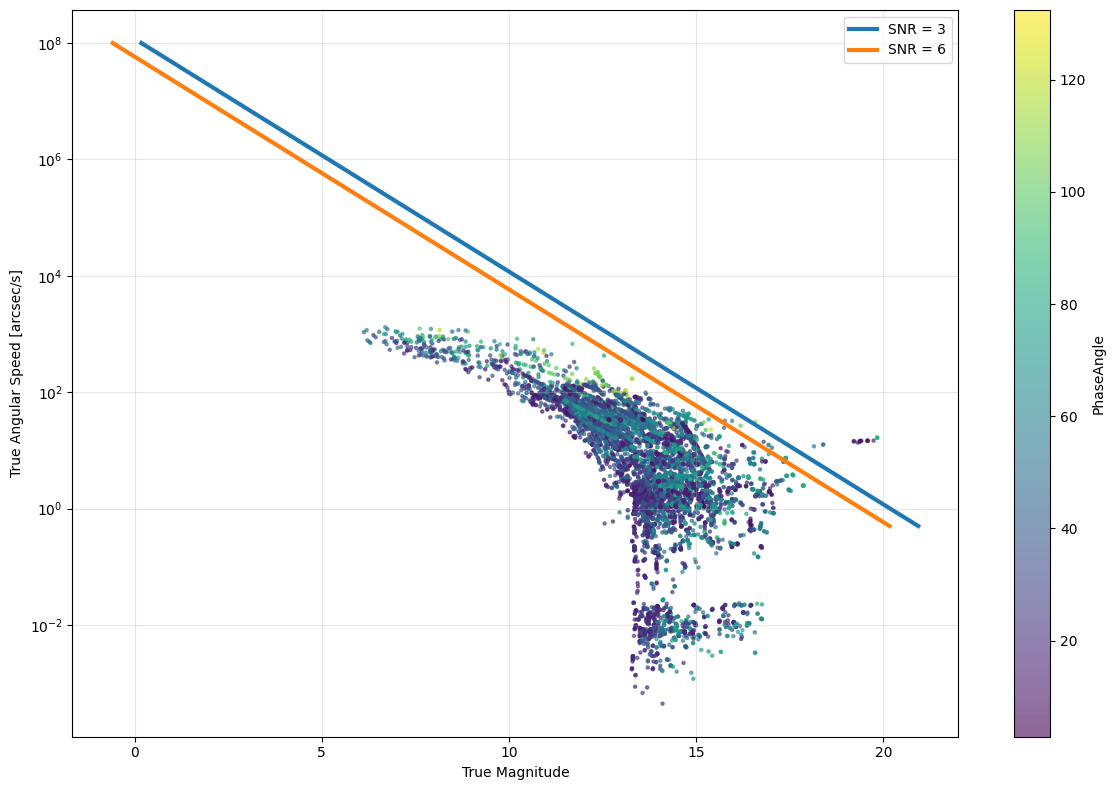

In [18]:
plot_mag_vs_speed(df_all)

## Histogramas

In [19]:
import matplotlib.pyplot as plt

def plot_histogram(
    df,
    column,
    bins=50,
    per_object=False,
    agg="median",
    xlabel=None,
    ylabel=None,
    title=None,
    color="green",
    edgecolor="black",
    log_x=False,
    log_y=False,
    min_value=None,
    max_value=None,
    text_x=0.65,
    text_y=0.92
):

    # Select data
    if per_object:
        data = (
            df.groupby("ObjectID")[column]
              .agg(agg)
              .dropna()
        )
        total = len(data)

    else:
        data = df[column].dropna()
        total = len(data)

    # Optional filtering
    if min_value is not None:
        data = data[data >= min_value]

    if max_value is not None:
        data = data[data <= max_value]

    shown = len(data)

    # Plot
    plt.figure(figsize=(12,6))

    plt.hist(
        data,
        bins=bins,
        color=color,
        edgecolor=edgecolor
    )

    if log_x:
        plt.xscale("log")

    if log_y:
        plt.yscale("log")

    if xlabel is None:
        xlabel = column

    if ylabel is None:
        ylabel = (
            "Number of objects"
            if per_object
            else "Number of detections"
        )

    if title is None:
        title = f"{column} distribution"

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    plt.text(
        text_x,
        text_y,
        f"Shown: {shown} / {total} "
        f"{'objects' if per_object else 'detections'}",
        transform=plt.gca().transAxes
    )

    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

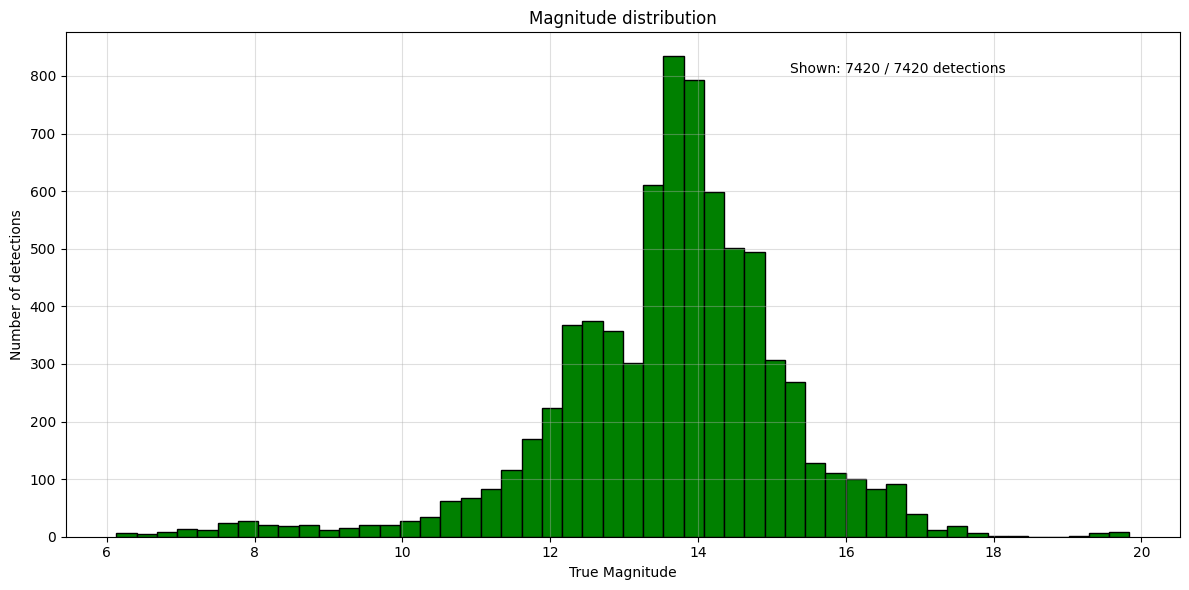

In [20]:
plot_histogram(
    df_all,
    "TrueMagnitude",
    xlabel="True Magnitude",
    title="Magnitude distribution"
)

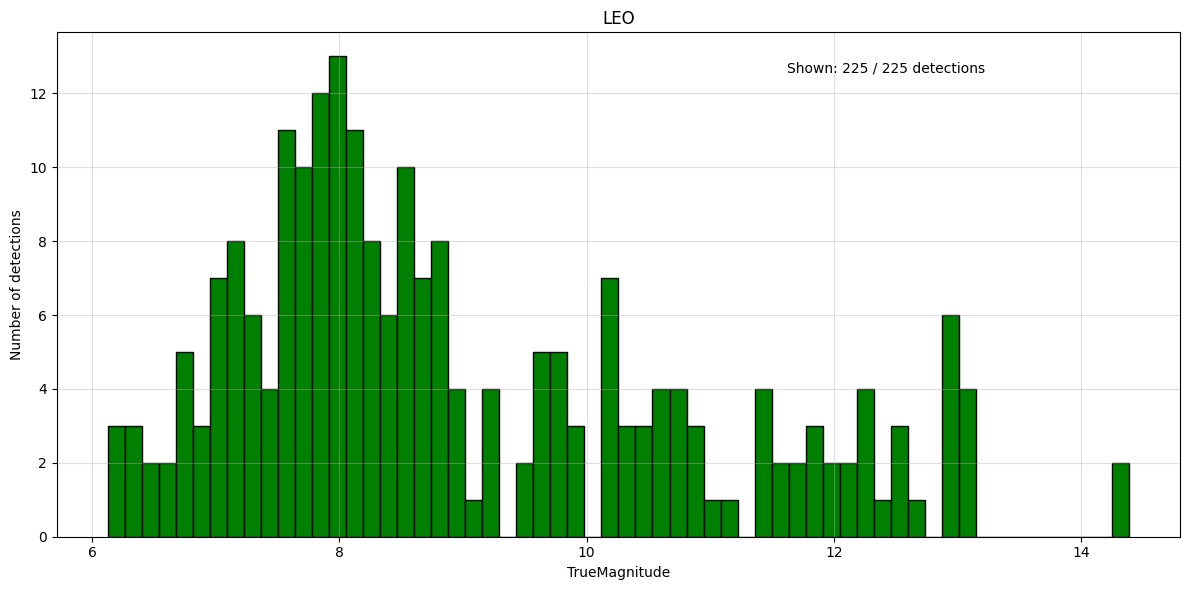

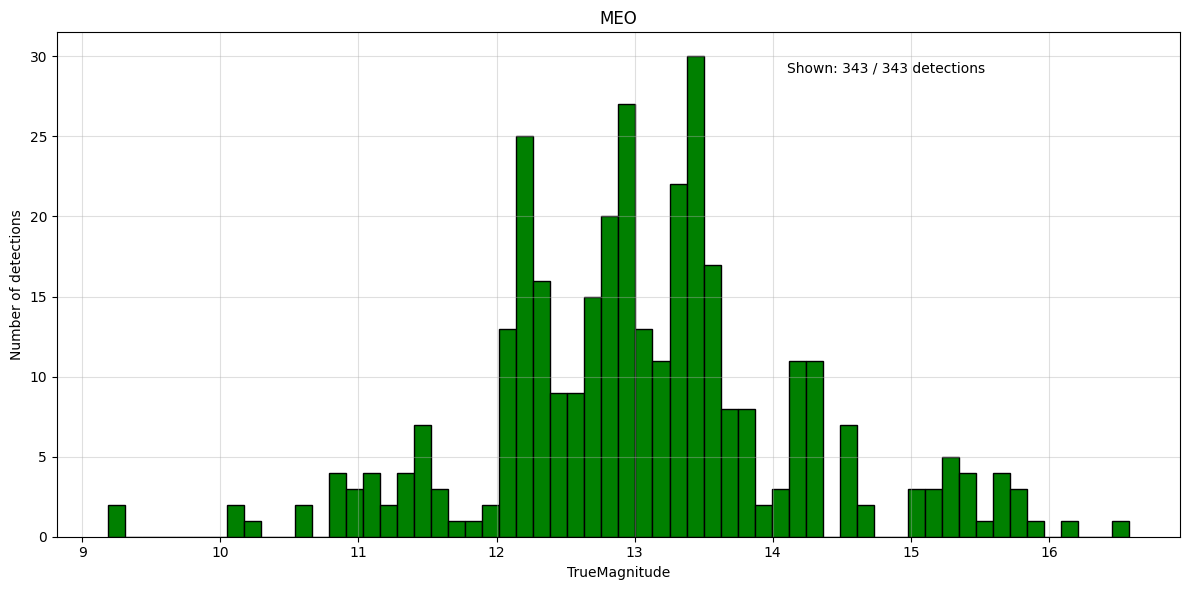

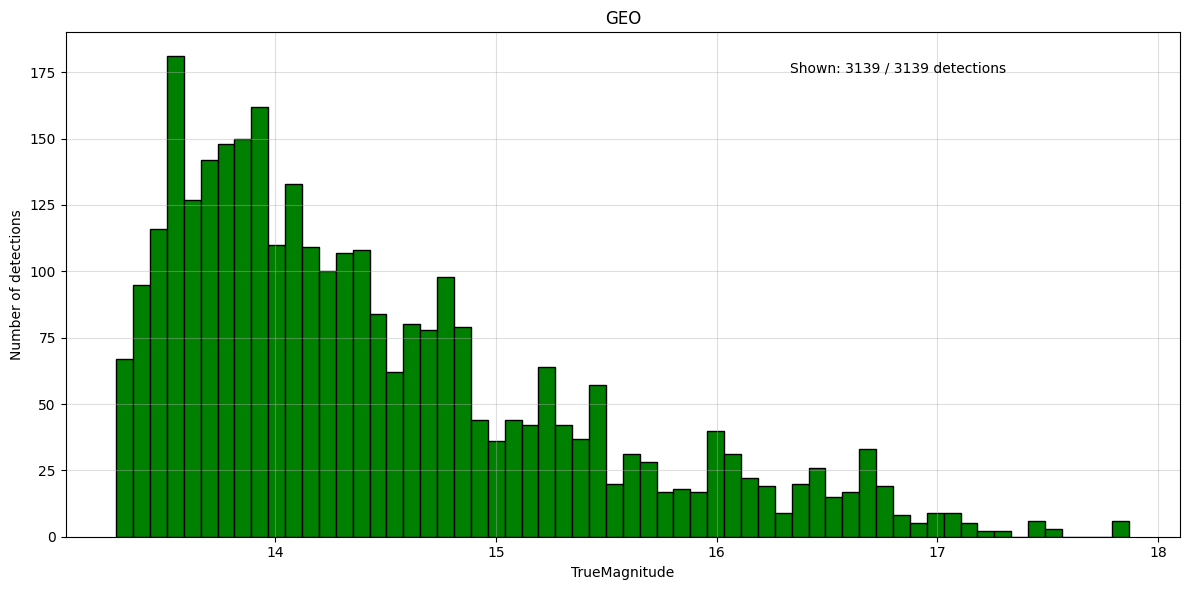

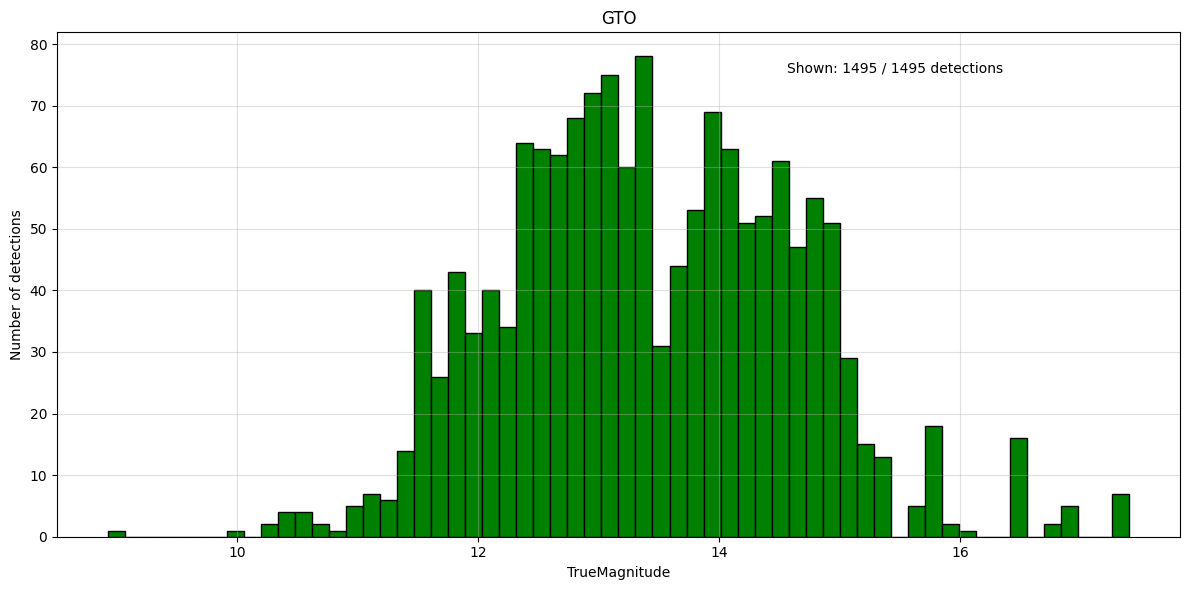

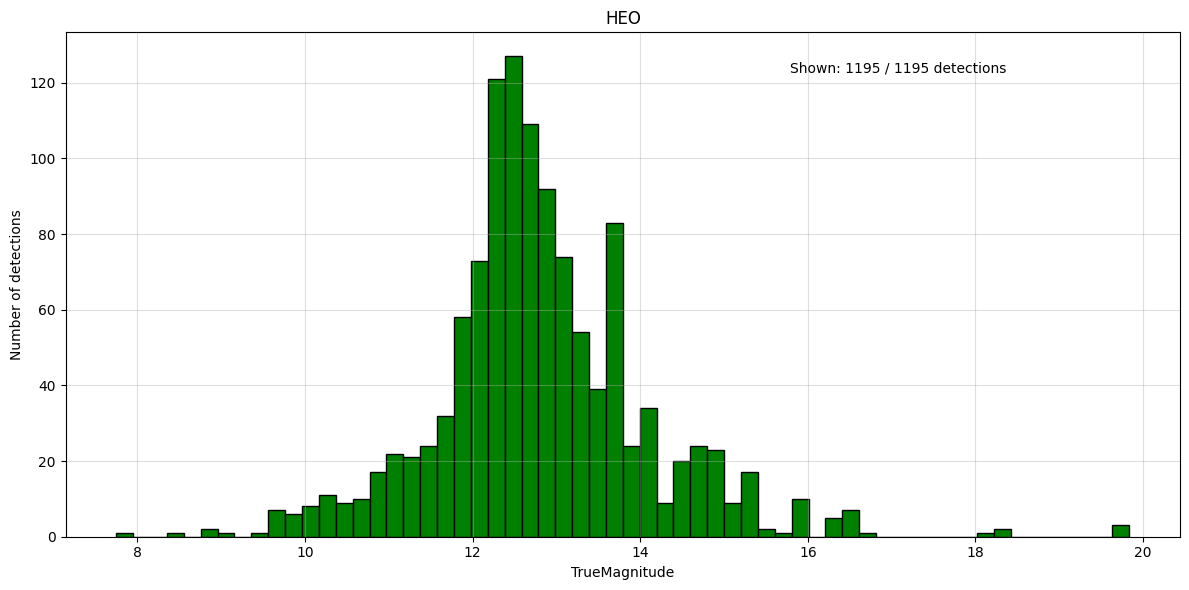

In [21]:
for orbit in ["LEO","MEO","GEO","GTO","HEO"]:
     plot_histogram(
            df_all[df_all["OrbitClass"]==orbit],
            "TrueMagnitude",
            bins=60,
            title=orbit
        )

In [62]:
# Read complete input catalogue
df_catalogue = read_objects_catalogue(OBJECTS_FILE)

# Normalized NORAD identifier
df_catalogue["NORAD_ID"] = df_catalogue["ObjectID"].apply(norm_id)

# Read SATCAT
sat = read_satcat(SATCAT_FILE)
sat["NORAD_ID"] = sat["ObjectID"].apply(norm_id)

sat = sat.drop_duplicates(
    subset="NORAD_ID",
    keep="first"
)

# Merge catalogue with SATCAT
df_catalogue = df_catalogue.merge(
    sat,
    on="NORAD_ID",
    how="left",
    suffixes=("", "_SAT")
)

# SATCAT orbital information first,
# SSDSIM ObjectCatalogue as fallback
df_catalogue["Perigee"] = (
    pd.to_numeric(
        df_catalogue["PERIGEE"],
        errors="coerce"
    ).combine_first(
        pd.to_numeric(
            df_catalogue["Perigee_SSDSIM"],
            errors="coerce"
        )
    )
)

df_catalogue["Apogee"] = (
    pd.to_numeric(
        df_catalogue["APOGEE"],
        errors="coerce"
    ).combine_first(
        pd.to_numeric(
            df_catalogue["Apogee_SSDSIM"],
            errors="coerce"
        )
    )
)

# Calculate eccentricity using the same method as for detections
df_catalogue["Eccentricity"] = [
    calculate_eccentricity(perigee, apogee)
    for perigee, apogee
    in zip(
        df_catalogue["Perigee"],
        df_catalogue["Apogee"]
    )
]

# Apply exactly the same orbital classification criteria
df_catalogue["OrbitClass"] = df_catalogue.apply(
    classify_orbit,
    axis=1
)

print("Total catalogue objects:", df_catalogue["NORAD_ID"].nunique())

print(
    df_catalogue.groupby("OrbitClass")["NORAD_ID"]
                .nunique()
)

Total catalogue objects: 27555
OrbitClass
GEO        1629
GTO         616
HEO         573
LEO       22979
MEO         609
Others     1149
Name: NORAD_ID, dtype: int64


In [63]:
orbit_classes = [
    "LEO",
    "MEO",
    "GEO",
    "GTO",
    "HEO",
    "Others"
]

rows = []

for orbit in orbit_classes:

    # Total objects of this class in the complete input catalogue
    n_catalogue = df_catalogue.loc[
        df_catalogue["OrbitClass"] == orbit,
        "NORAD_ID"
    ].nunique()

    # Unique objects detected with SNR >= 3
    n_snr3 = df_snr3.loc[
        df_snr3["OrbitClass"] == orbit,
        "ObjectID"
    ].nunique()

    # Unique objects detected with SNR >= 6
    n_snr6 = df_snr6.loc[
        df_snr6["OrbitClass"] == orbit,
        "ObjectID"
    ].nunique()

    # Detection fractions relative to the COMPLETE catalogue population
    p_snr3 = (
        100 * n_snr3 / n_catalogue
        if n_catalogue > 0 else 0
    )

    p_snr6 = (
        100 * n_snr6 / n_catalogue
        if n_catalogue > 0 else 0
    )

    rows.append({
        "OrbitClass": orbit,
        "Catalogue": n_catalogue,
        "SNR3": n_snr3,
        "SNR3_percent": p_snr3,
        "SNR6": n_snr6,
        "SNR6_percent": p_snr6,
    })

detection_by_orbit = pd.DataFrame(rows)

print(
    detection_by_orbit.to_string(
        index=False,
        formatters={
            "SNR3_percent": "{:.2f}".format,
            "SNR6_percent": "{:.2f}".format,
        }
    )
)

OrbitClass  Catalogue  SNR3 SNR3_percent  SNR6 SNR6_percent
       LEO      22979   179         0.78   179         0.78
       MEO        609   121        19.87   119        19.54
       GEO       1629   468        28.73   468        28.73
       GTO        616   186        30.19   185        30.03
       HEO        573   143        24.96   142        24.78
    Others       1149   223        19.41   223        19.41


In [64]:
catalogue_counts = (
    df_catalogue.groupby("OrbitClass")["NORAD_ID"]
    .nunique()
)

catalogue_percentages = (
    100 * catalogue_counts / catalogue_counts.sum()
)

print(
    pd.DataFrame({
        "Objects": catalogue_counts,
        "Percentage": catalogue_percentages
    })
)

            Objects  Percentage
OrbitClass                     
GEO            1629    5.911813
GTO             616    2.235529
HEO             573    2.079477
LEO           22979   83.393214
MEO             609    2.210125
Others         1149    4.169842


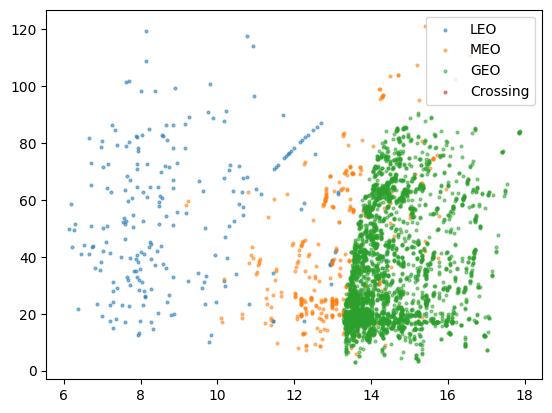

In [22]:
for orbit,color in zip(
    ["LEO","MEO","GEO","Crossing"],
    ["tab:blue","tab:orange","tab:green","tab:red"]
):

    d=df_all[df_all["OrbitClass"]==orbit]

    plt.scatter(
        d["TrueMagnitude"],
        d["PhaseAngle"],
        s=4,
        alpha=0.5,
        label=orbit,
        color=color
    )

#plt.yscale("log")
plt.legend()

### Plot by orbit class


In [23]:
def plot_mag_vs_speed_by_orbit(
    df,
    snr_curves=(3, 6),
    point_size=5,
    alpha=0.6,
    log_y=True,
):

    plt.figure(figsize=(12, 8))

    orbit_classes = [
        "LEO",
        "MEO",
        "GEO",
        "GTO",
        "HEO",
        "Others",
    ]

    # Plot detections separately for each orbital class
    for orbit in orbit_classes:

        subset = df[
            df["OrbitClass"] == orbit
        ]

        if subset.empty:
            continue

        plt.scatter(
            subset["TrueMagnitude"],
            subset["TrueAngularSpeed_arcsec_s"],
            s=point_size,
            alpha=alpha,
            label=orbit,
        )

    # Logarithmic angular speed axis
    if log_y:
        plt.yscale("log")

    # Plot SNR limiting curves
    if snr_curves is not None:

        omega = np.logspace(-0.3, 5, 50)

        for snr in snr_curves:

            mag_limit = []

            for w in omega:
                mag_limit.append(
                    find_magnitude_for_snr(
                        snr,
                        w * u.arcsec / u.s
                    )
                )

            plt.plot(
                mag_limit,
                omega,
                linewidth=3,
                label=f"SNR = {snr}",
            )

    plt.xlabel("Apparent Magnitude")
    plt.ylabel("Angular Speed [arcsec/s]")
    plt.title("Angular speed vs apparent magnitude")

    plt.grid(
        True,
        which="both",
        alpha=0.3,
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

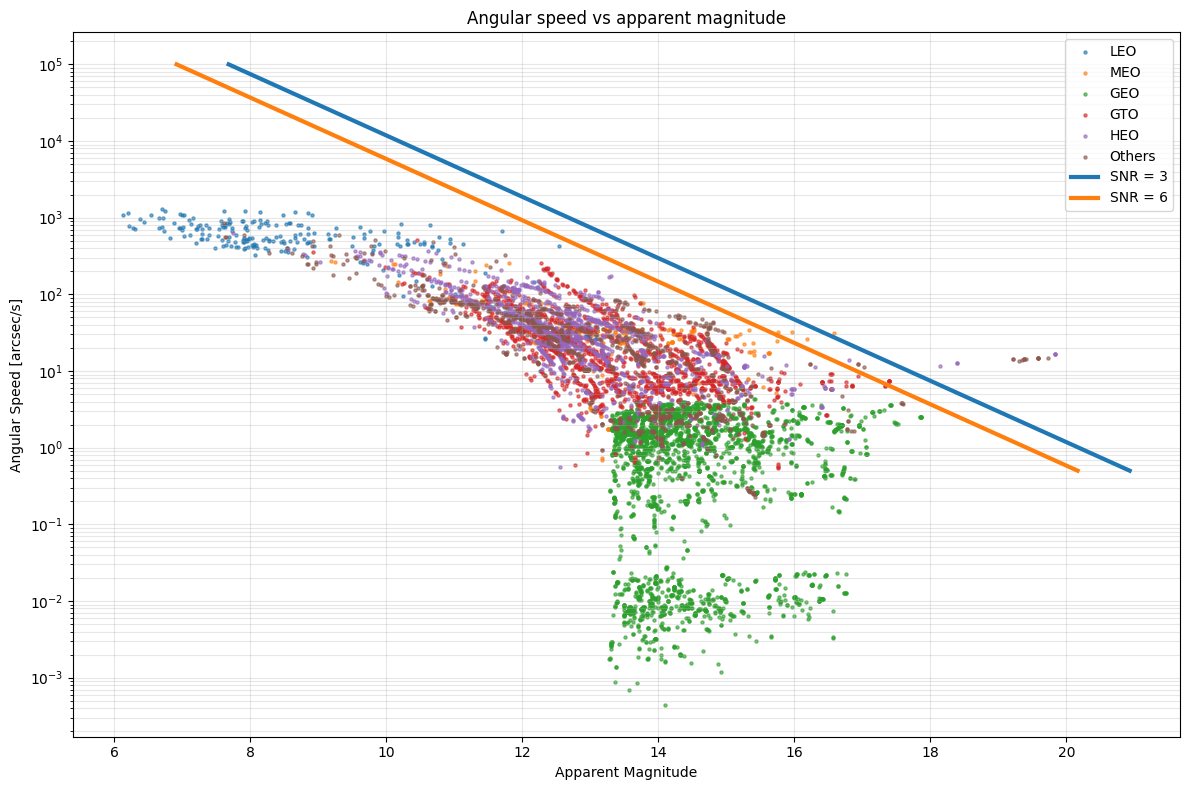

In [24]:
plot_mag_vs_speed_by_orbit(
    df_all,
    snr_curves=(3, 6),
)

In [25]:
import matplotlib.pyplot as plt

def plot_by_orbit_class(
    df,
    x,
    y,
    orbit_classes=("LEO","MEO","GEO","GTO","HEO"),
    colors=("tab:blue","tab:orange","tab:green","tab:red","tab:purple"),
    xlabel=None,
    ylabel=None,
    title=None,
    point_size=4,
    alpha=0.5,
    log_x=False,
    log_y=False,
    xlim=None,
    ylim=None,
):

    plt.figure(figsize=(10,6))

    for orbit, color in zip(orbit_classes, colors):

        d = df[df["OrbitClass"] == orbit]

        plt.scatter(
            d[x],
            d[y],
            s=point_size,
            alpha=alpha,
            color=color,
            label=orbit
        )

    if log_x:
        plt.xscale("log")

    if log_y:
        plt.yscale("log")

    plt.xlabel(xlabel if xlabel is not None else x)
    plt.ylabel(ylabel if ylabel is not None else y)

    if title is not None:
        plt.title(title)

    if xlim is not None:
        plt.xlim(xlim)

    if ylim is not None:
        plt.ylim(ylim)

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

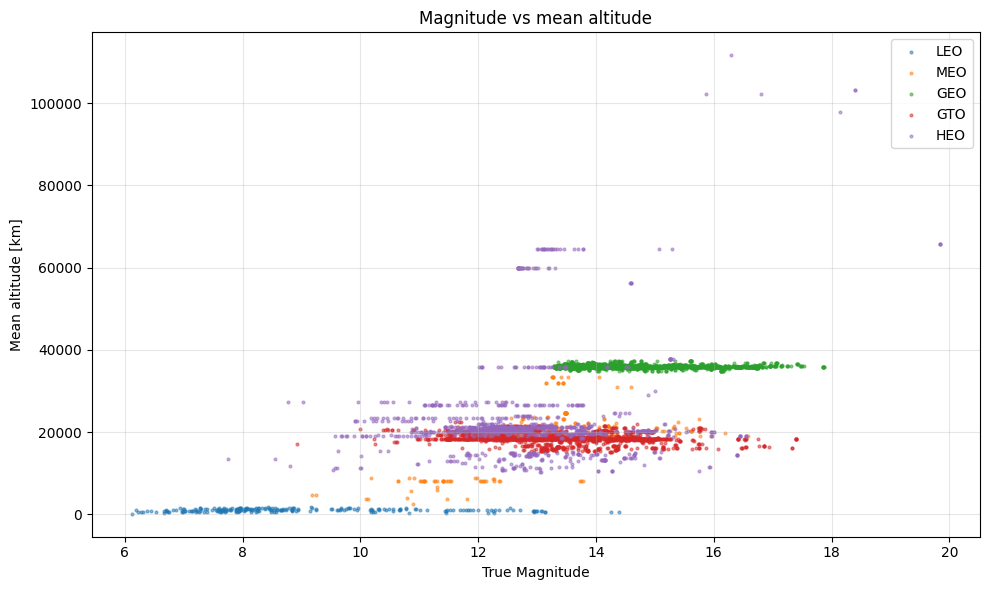

In [26]:
plot_by_orbit_class(
    df_all,
    x="TrueMagnitude",
    y="MeanAltitude",
    xlabel="True Magnitude",
    ylabel="Mean altitude [km]",
    title="Magnitude vs mean altitude"
)

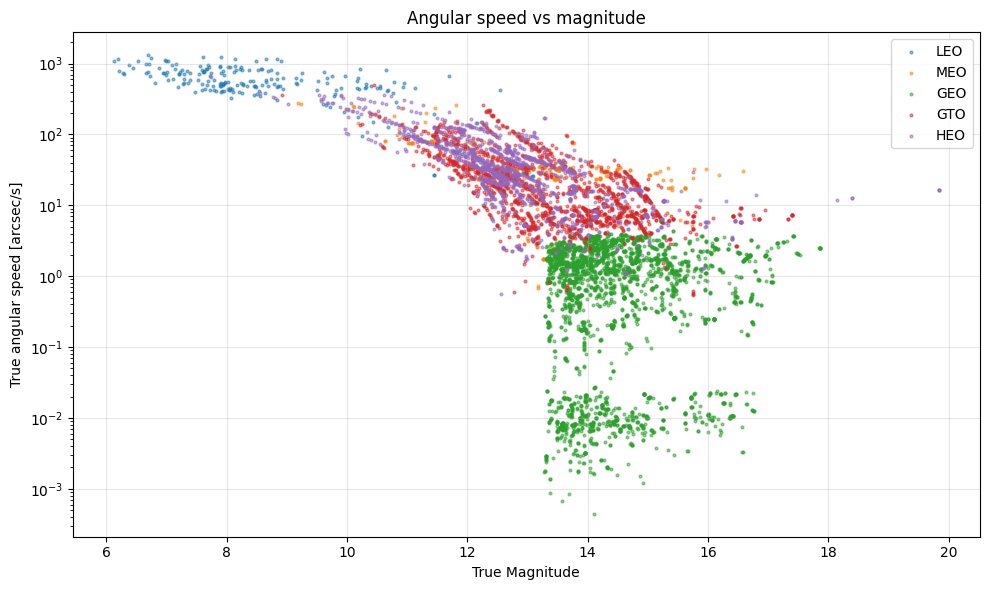

In [27]:
plot_by_orbit_class(
    df_all,
    x="TrueMagnitude",
    y="TrueAngularSpeed_arcsec_s",
    xlabel="True Magnitude",
    ylabel="True angular speed [arcsec/s]",
    title="Angular speed vs magnitude",
    log_y=True
)

## Other graphics

In [28]:
def plot_scatter(
    df,
    x,
    y,
    color_by=None,
    xlabel=None,
    ylabel=None,
    title=None,
    log_x=False,
    log_y=False,
    max_x=None,
    max_y=None,
    color_max=None
):

    data = df.copy()

    # Optional filtering
    if max_x is not None:
        data = data[data[x] <= max_x]

    if max_y is not None:
        data = data[data[y] <= max_y]

    plt.figure(figsize=(12, 7))

    if color_by is None:

        plt.scatter(
            data[x],
            data[y],
            s=8,
            alpha=0.5
        )

    else:

        sc = plt.scatter(
            data[x],
            data[y],
            c=data[color_by],
            cmap="viridis",
            s=8,
            alpha=0.5,
            vmax=color_max
        )

        cbar = plt.colorbar(sc)
        cbar.set_label(color_by)

    if log_x:
        plt.xscale("log")

    if log_y:
        plt.yscale("log")

    plt.xlabel(xlabel if xlabel else x)
    plt.ylabel(ylabel if ylabel else y)
    plt.title(title if title else f"{y} vs {x}")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

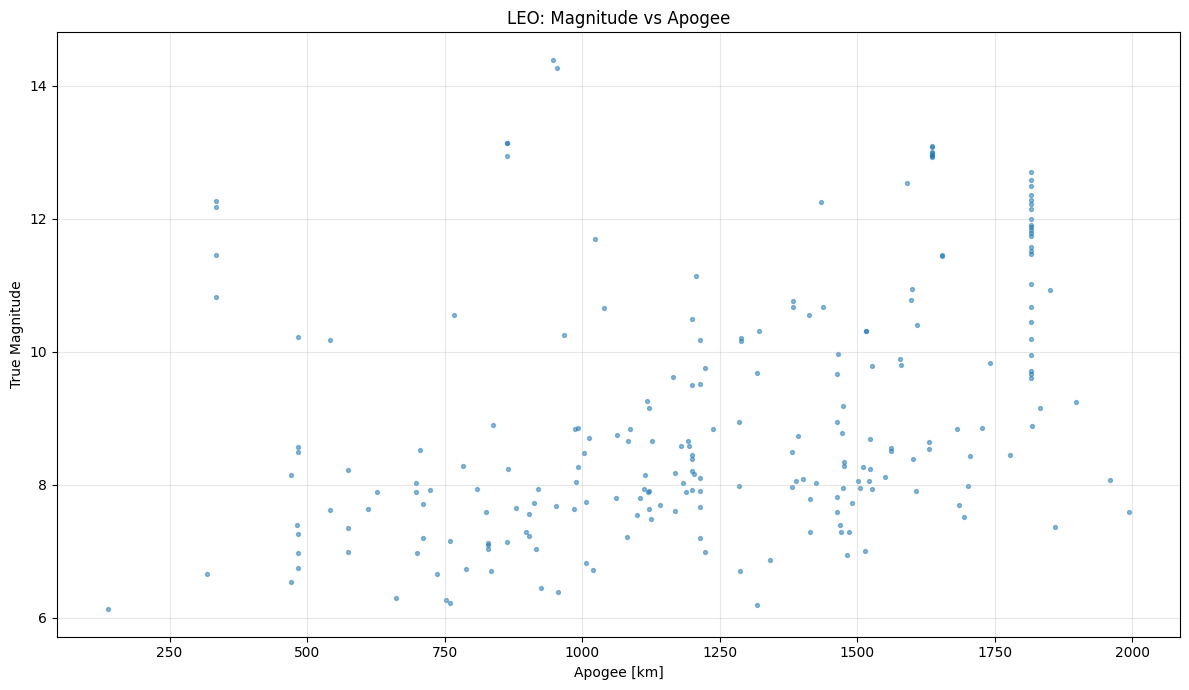

In [29]:
leo = df_all[df_all["OrbitClass"] == "LEO"]
plot_scatter(
    leo,
    x="Apogee",
    y="TrueMagnitude",
    xlabel="Apogee [km]",
    ylabel="True Magnitude",
    title="LEO: Magnitude vs Apogee"
)

In [30]:
df_snr6.groupby("OrbitClass")["ObjectID"].nunique().sort_values(ascending=False)

OrbitClass
GEO       468
Others    223
GTO       185
LEO       179
HEO       142
MEO       119
Name: ObjectID, dtype: int64

In [31]:
df_snr6["OrbitClass"].value_counts()

OrbitClass
GEO       3139
GTO       1490
HEO       1187
Others    1007
MEO        339
LEO        225
Name: count, dtype: int64

## Some statistics


In [60]:
import matplotlib.pyplot as plt

def detection_statistics(
    df,
    output_csv=None,
    bins=70,
    min_value=None,
    max_value=None,
    xlim=None,
    log_y=False,
):

    # Count detections per object
    object_counts = df["ObjectID"].value_counts().sort_index()

    print(f"Number of unique objects: {len(object_counts)}")
    print(f"Number of detections: {len(df)}")

    print(f"\nMinimum detections: {object_counts.min()}")
    print(f"Maximum detections: {object_counts.max()}")
    print(f"Mean detections per object: {object_counts.mean():.2f}")
    print(f"Median detections per object: {object_counts.median():.2f}")

    max_obj = object_counts.idxmax()
    print(f"\nMost observed object: {max_obj} ({object_counts.max()} detections)")

    min_obj = object_counts.idxmin()
    print(f"Least observed object: {min_obj} ({object_counts.min()} detection)")

    print("\nDetection count percentiles:")
    print(f"10th percentile: {object_counts.quantile(0.10):.0f}")
    print(f"25th percentile: {object_counts.quantile(0.25):.0f}")
    print(f"50th percentile: {object_counts.quantile(0.50):.0f}")
    print(f"75th percentile: {object_counts.quantile(0.75):.0f}")
    print(f"90th percentile: {object_counts.quantile(0.90):.0f}")

    if output_csv is not None:
        object_counts.rename("Detections").to_csv(
            output_csv,
            header=True
        )

        print(f"\nFile saved: {output_csv}")

    #Filter only for plotting 
    object_counts_plot = object_counts.copy()

    if min_value is not None:
        object_counts_plot = object_counts_plot[object_counts_plot >= min_value]

    if max_value is not None:
        object_counts_plot = object_counts_plot[object_counts_plot <= max_value]

   # Plot
    plt.figure(figsize=(10,5))

    plt.hist(
        object_counts_plot,
        bins=bins,
        color="green",
        edgecolor="black"
    )

    if xlim is not None:
        plt.xlim(xlim)

    if log_y:
        plt.yscale("log")

    plt.xlabel("Number of detections", fontsize=25)
    plt.ylabel("Number of objects", fontsize=25)
    plt.title("Detection distribution per object (TFRM)", fontsize=25)

    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    #plt.text(
     #   0.60,
      #  0.92,
       # f"Shown: {len(object_counts_plot)} / {len(object_counts)} objects",
        #transform=plt.gca().transAxes,
        #fontsize=16
    #)

    plt.grid(True, alpha=0.4)
    plt.tight_layout()

    filename = "TFRMDetectionsPerObject.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return object_counts


Number of unique objects: 1320
Number of detections: 7400

Minimum detections: 1
Maximum detections: 61
Mean detections per object: 5.61
Median detections per object: 3.00

Most observed object: 27046 (61 detections)
Least observed object: 261 (1 detection)

Detection count percentiles:
10th percentile: 1
25th percentile: 1
50th percentile: 3
75th percentile: 6
90th percentile: 14

File saved: object_detection_counts_all_TFRM.csv


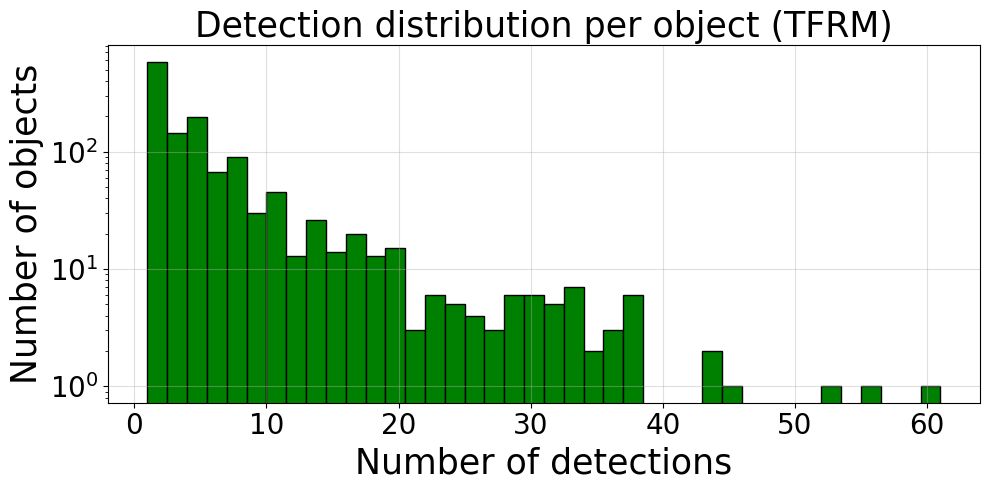

In [61]:
counts_all = detection_statistics(
    df_snr3,
    output_csv="object_detection_counts_all_TFRM.csv",
    bins=40,
    log_y=True
)


Number of unique objects: 1326
Number of detections: 7420

Minimum detections: 1
Maximum detections: 61
Mean detections per object: 5.60
Median detections per object: 3.00

Most observed object: 27046 (61 detections)
Least observed object: 261 (1 detection)

Detection count percentiles:
10th percentile: 1
25th percentile: 1
50th percentile: 3
75th percentile: 6
90th percentile: 14

File saved: object_detection_counts_all.csv


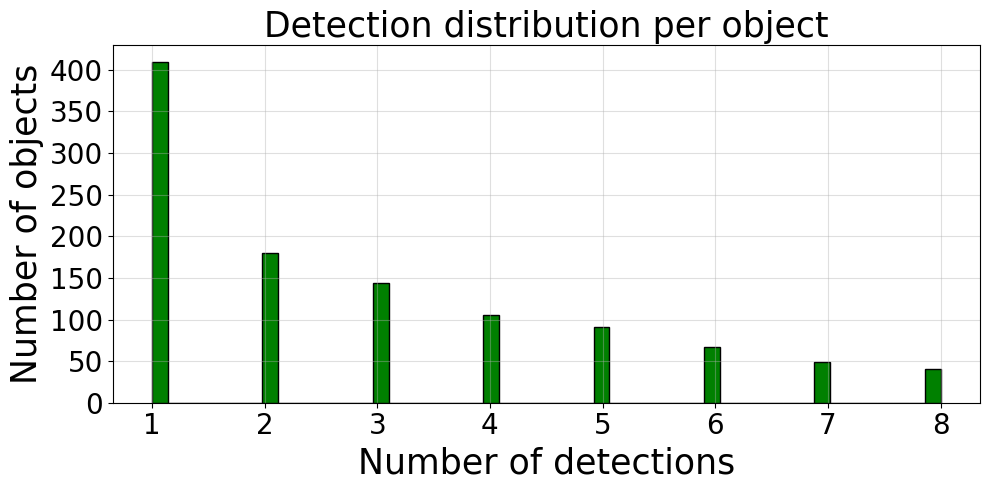

In [72]:
counts_all = detection_statistics(
    df_all,
    output_csv="object_detection_counts_all.csv",
    max_value=8
)

Number of unique objects: 1320
Number of detections: 7400

Minimum detections: 1
Maximum detections: 61
Mean detections per object: 5.61
Median detections per object: 3.00

Most observed object: 27046 (61 detections)
Least observed object: 261 (1 detection)

Detection count percentiles:
10th percentile: 1
25th percentile: 1
50th percentile: 3
75th percentile: 6
90th percentile: 14

File saved: object_detection_counts_snr3_TFRM.csv


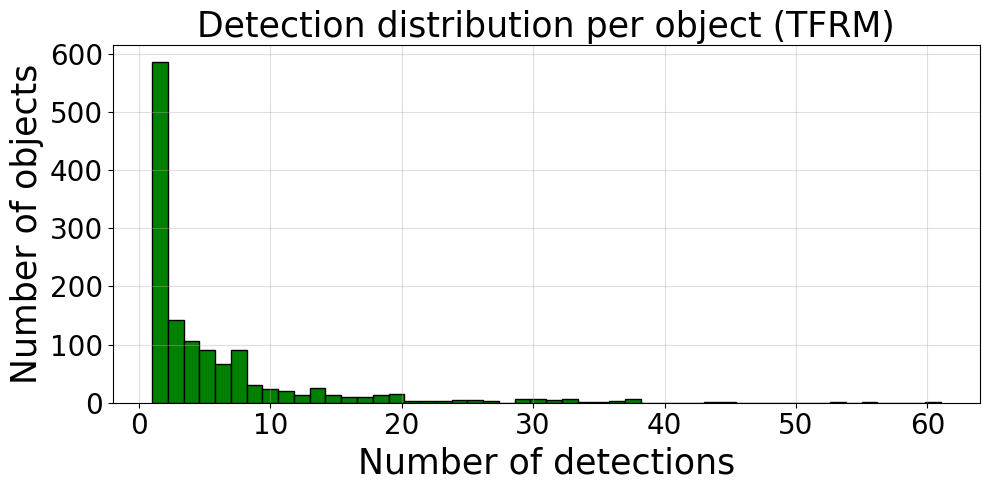

In [89]:
counts_snr3 = detection_statistics(
    df_snr3,
    output_csv="object_detection_counts_snr3_TFRM.csv"
)

Number of unique objects: 1316
Number of detections: 7387

Minimum detections: 1
Maximum detections: 61
Mean detections per object: 5.61
Median detections per object: 3.00

Most observed object: 27046 (61 detections)
Least observed object: 261 (1 detection)

Detection count percentiles:
10th percentile: 1
25th percentile: 1
50th percentile: 3
75th percentile: 6
90th percentile: 14

File saved: object_detection_counts_snr6_TFR.csv


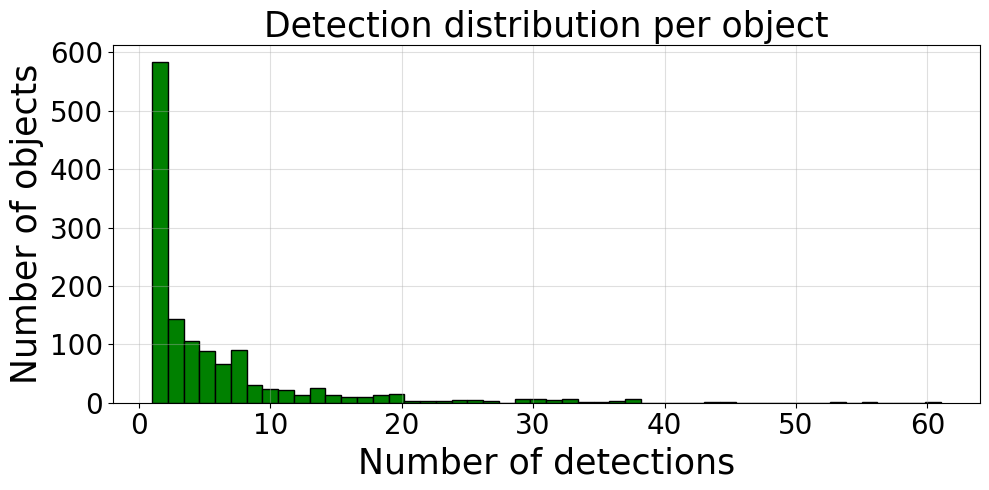

In [74]:
counts_snr6 = detection_statistics(
    df_snr6,
    output_csv="object_detection_counts_snr6_TFR.csv"
)

In [75]:
n_single_all = (counts_all == 1).sum()
n_single_snr3 = (counts_snr3 == 1).sum()
n_single_snr6 = (counts_snr6 == 1).sum()

print(f"All detections: objects with exactly 1 detection = {n_single_all}")
print(f"SNR >= 3: objects with exactly 1 detection = {n_single_snr3}")
print(f"SNR >= 6: objects with exactly 1 detection = {n_single_snr6}")

All detections: objects with exactly 1 detection = 409
SNR >= 3: objects with exactly 1 detection = 407
SNR >= 6: objects with exactly 1 detection = 406


### Orbit class summary 

In [42]:
def orbit_summary(df, name="dataset"):

    summary = (
        df.groupby("OrbitClass")
        .agg(
            detections=("ObjectID", "size"),
            unique_objects=("ObjectID", "nunique"),

            mean_magnitude=("TrueMagnitude", "mean"),
            median_magnitude=("TrueMagnitude", "median"),
            min_magnitude=("TrueMagnitude", "min"),
            max_magnitude=("TrueMagnitude", "max"),

            mean_altitude=("MeanAltitude", "mean"),
            median_altitude=("MeanAltitude", "median"),

            mean_speed=("TrueAngularSpeed_arcsec_s", "mean"),
            median_speed=("TrueAngularSpeed_arcsec_s", "median"),
        )
        .sort_values("unique_objects", ascending=False)
    )

    print(f"\n{name}")
    display(summary)

    return summary
    return summary

summary_all = orbit_summary(df_all, "All FoV crossings")
summary_snr3 = orbit_summary(df_snr3, "SNR >= 3")
summary_snr6 = orbit_summary(df_snr6, "SNR >= 6")


All FoV crossings


,detections,unique_objects,mean_magnitude,median_magnitude,min_magnitude,max_magnitude,mean_altitude,median_altitude,mean_speed,median_speed
OrbitClass,,,,,,,,,,
GEO,3139,468,14.470495,14.232592,13.281367,17.868883,35925.574387,35787.5,1.206756,1.077838
Others,1023,225,13.323483,13.591893,7.617854,19.738580,28254.804985,22751.5,40.747548,16.656673
GTO,1495,186,13.426490,13.339217,8.926812,17.398400,18530.082943,18387.5,28.413589,13.799269
LEO,225,179,9.008041,8.449534,6.127687,14.387700,1034.382222,985.5,540.446919,520.973800
HEO,1195,146,12.809300,12.656677,7.748977,19.835882,22843.483682,20310.0,49.535984,29.634362
MEO,343,122,13.063183,13.002902,9.186584,16.579060,19018.642857,19130.5,39.072321,32.336346



SNR >= 3


,detections,unique_objects,mean_magnitude,median_magnitude,min_magnitude,max_magnitude,mean_altitude,median_altitude,mean_speed,median_speed
OrbitClass,,,,,,,,,,
GEO,3139,468,14.470495,14.232592,13.281367,17.868883,35925.574387,35787.5,1.206756,1.077838
Others,1010,223,13.244764,13.561963,7.617854,17.598501,23577.000000,22718.0,41.086542,16.839096
GTO,1495,186,13.426490,13.339217,8.926812,17.398400,18530.082943,18387.5,28.413589,13.799269
LEO,225,179,9.008041,8.449534,6.127687,14.387700,1034.382222,985.5,540.446919,520.973800
HEO,1189,143,12.777689,12.650054,7.748977,16.804308,22537.043314,20310.0,49.713130,29.667993
MEO,342,121,13.052903,13.000103,9.186584,16.189346,19018.317251,19130.5,39.095981,32.338105



SNR >= 6


,detections,unique_objects,mean_magnitude,median_magnitude,min_magnitude,max_magnitude,mean_altitude,median_altitude,mean_speed,median_speed
OrbitClass,,,,,,,,,,
GEO,3139,468,14.470495,14.232592,13.281367,17.868883,35925.574387,35787.5,1.206756,1.077838
Others,1007,223,13.233683,13.557198,7.617854,17.598501,23364.035750,22718.0,41.173335,16.954609
GTO,1490,185,13.413179,13.332686,8.926812,17.333049,18530.534564,18387.5,28.484188,13.911694
LEO,225,179,9.008041,8.449534,6.127687,14.387700,1034.382222,985.5,540.446919,520.973800
HEO,1187,142,12.771796,12.650041,7.748977,16.554256,22480.009267,20310.0,49.760220,29.695191
MEO,339,119,13.027069,12.979808,9.186584,15.744937,19015.227139,19130.5,39.173451,32.356443


In [43]:
def category_summary(df, column, name="dataset"):
    summary = (
        df.drop_duplicates("ObjectID")[column]
        .value_counts(dropna=False)
        .to_frame("unique_objects")
    )

    summary["percentage"] = (
        100 * summary["unique_objects"] / summary["unique_objects"].sum()
    )

    print(f"\n{name} — {column}")
    display(summary)

    return summary

type_all = category_summary(df_all, "ObjectType", "All FoV crossings")
type_snr3 = category_summary(df_snr3, "ObjectType", "SNR >= 3")
type_snr6 = category_summary(df_snr6, "ObjectType", "SNR >= 6")

active_all = category_summary(df_all, "OperationalStatus", "All FoV crossings")
active_snr3 = category_summary(df_snr3, "OperationalStatus", "SNR >= 3")
active_snr6 = category_summary(df_snr6, "OperationalStatus", "SNR >= 6")


All FoV crossings — ObjectType


,unique_objects,percentage
ObjectType,,
PAY,581,43.815988
DEB,400,30.165913
R/B,345,26.018100



SNR >= 3 — ObjectType


,unique_objects,percentage
ObjectType,,
PAY,577,43.712121
DEB,400,30.303030
R/B,343,25.984848



SNR >= 6 — ObjectType


...

,unique_objects,percentage
OperationalStatus,,
Unknown,805,60.708899
Nonoperational,251,18.929110
Operational,242,18.250377
Partially operational,11,0.829563
Decayed,11,0.829563
Backup/standby,4,0.301659
Spare,2,0.150830



SNR >= 3 — OperationalStatus


,unique_objects,percentage
OperationalStatus,,
Unknown,802,60.757576
Nonoperational,250,18.939394
Operational,240,18.181818
Partially operational,11,0.833333
Decayed,11,0.833333
Backup/standby,4,0.303030
Spare,2,0.151515



SNR >= 6 — OperationalStatus


,unique_objects,percentage
OperationalStatus,,
Unknown,799,60.714286
Nonoperational,249,18.920973
Operational,240,18.237082
Partially operational,11,0.835866
Decayed,11,0.835866
Backup/standby,4,0.303951
Spare,2,0.151976


### Statistics on arc duration and obervation time

In [44]:
from pathlib import Path
import pandas as pd


def read_visibilities(filename):
    """
    Read the SSDSIM SurveyVisibilities.dat format used in this work.

    Each visibility entry contains:
    start time, stop time, sensor ID, carrier ID,
    object identifier and mean angular accuracy.
    """
    rows = []

    with Path(filename).open(errors="ignore") as file:
        for line in file:
            line = line.strip()

            if (
                not line
                or line.startswith(
                    (
                        "FileName",
                        "FileStartTime",
                        "FileStopTime",
                        "VisibList",
                        "endlist",
                    )
                )
            ):
                continue

            parts = line.split()

            if len(parts) != 6:
                continue

            try:
                start = pd.to_datetime(
                    parts[0],
                    format="%Y/%m/%d-%H:%M:%S.%f",
                )

                stop = pd.to_datetime(
                    parts[1],
                    format="%Y/%m/%d-%H:%M:%S.%f",
                )

            except ValueError:
                continue

            rows.append(
                {
                    "StartTime": start,
                    "StopTime": stop,
                    "SensorID": parts[2],
                    "CarrierID": parts[3],
                    "ObjectID": parts[4],
                    "MeanAccuracy": pd.to_numeric(
                        parts[5],
                        errors="coerce",
                    ),
                }
            )

    vis = pd.DataFrame(rows)

    if vis.empty:
        raise ValueError(
            f"No visibility entries could be read from {filename}."
        )

    vis["ArcDuration_s"] = (
        vis["StopTime"] - vis["StartTime"]
    ).dt.total_seconds()

    vis["ArcDuration_min"] = vis["ArcDuration_s"] / 60.0

    vis = vis[vis["ArcDuration_s"] > 0].copy()

    return vis

In [45]:
vis_photsat = read_visibilities("visibilities_TFRM_SSDSIM.dat")

print(vis_photsat.head())
print()
print(vis_photsat["ArcDuration_min"].describe())

                StartTime                StopTime SensorID CarrierID ObjectID  \
0 2025-06-21 22:18:00.726 2025-06-21 22:18:13.439     TFRM  TFRM____  61015CH   
1 2025-06-23 02:12:26.001 2025-06-23 02:12:56.000     TFRM  TFRM____   62029A   
2 2025-06-23 02:12:56.000 2025-06-23 02:13:26.000     TFRM  TFRM____   62029A   
3 2025-06-22 01:23:47.001 2025-06-22 01:24:17.000     TFRM  TFRM____   63004A   
4 2025-06-22 01:26:17.001 2025-06-22 01:26:47.000     TFRM  TFRM____   63004A   

   MeanAccuracy  ArcDuration_s  ArcDuration_min  
0           0.1         12.713         0.211883  
1           0.1         29.999         0.499983  
2           0.1         30.000         0.500000  
3           0.1         29.999         0.499983  
4           0.1         29.999         0.499983  

count    7420.000000
mean        0.490848
std         0.042451
min         0.200500
25%         0.499983
50%         0.499983
75%         0.499983
max         0.500000
Name: ArcDuration_min, dtype: float64


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def merge_continuous_visibility_arcs(
    vis,
    max_gap_seconds=1.0,
):
    
    #Merge consecutive or overlapping visibility intervals belonging to the same object.

    #Two intervals are considered part of the same continuous arc when the gap between them is smaller than or equal to max_gap_seconds.
    
    required_columns = {
        "ObjectID",
        "StartTime",
        "StopTime",
    }

    missing = required_columns - set(vis.columns)

    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    data = vis.copy()

    data["StartTime"] = pd.to_datetime(
        data["StartTime"],
        errors="coerce",
    )

    data["StopTime"] = pd.to_datetime(
        data["StopTime"],
        errors="coerce",
    )

    data = data.dropna(
        subset=["ObjectID", "StartTime", "StopTime"]
    )

    data = data[
        data["StopTime"] > data["StartTime"]
    ].copy()

    data = data.sort_values(
        ["ObjectID", "StartTime", "StopTime"]
    )

    merged_rows = []

    for object_id, group in data.groupby(
        "ObjectID",
        sort=False,
    ):
        group = group.sort_values("StartTime")

        current_start = None
        current_stop = None
        sensor_id = None
        carrier_id = None
        number_of_segments = 0

        for row in group.itertuples(index=False):
            start = row.StartTime
            stop = row.StopTime

            if current_start is None:
                current_start = start
                current_stop = stop
                sensor_id = getattr(row, "SensorID", np.nan)
                carrier_id = getattr(row, "CarrierID", np.nan)
                number_of_segments = 1
                continue

            gap_seconds = (
                start - current_stop
            ).total_seconds()

            if gap_seconds <= max_gap_seconds:
                # Same continuous observation arc
                current_stop = max(current_stop, stop)
                number_of_segments += 1

            else:
                merged_rows.append(
                    {
                        "ObjectID": object_id,
                        "SensorID": sensor_id,
                        "CarrierID": carrier_id,
                        "ArcStartTime": current_start,
                        "ArcStopTime": current_stop,
                        "NumberOfSegments": number_of_segments,
                    }
                )

                current_start = start
                current_stop = stop
                sensor_id = getattr(row, "SensorID", np.nan)
                carrier_id = getattr(row, "CarrierID", np.nan)
                number_of_segments = 1

        # Store final arc of each object
        if current_start is not None:
            merged_rows.append(
                {
                    "ObjectID": object_id,
                    "SensorID": sensor_id,
                    "CarrierID": carrier_id,
                    "ArcStartTime": current_start,
                    "ArcStopTime": current_stop,
                    "NumberOfSegments": number_of_segments,
                }
            )

    arcs = pd.DataFrame(merged_rows)

    arcs["ArcDuration_s"] = (
        arcs["ArcStopTime"] - arcs["ArcStartTime"]
    ).dt.total_seconds()

    arcs["ArcDuration_min"] = (
        arcs["ArcDuration_s"] / 60.0
    )

    return arcs

In [47]:
arcs_photsat = merge_continuous_visibility_arcs(
    vis_photsat,
    max_gap_seconds=1.0,
)

print(arcs_photsat.head())
print()
print(arcs_photsat["ArcDuration_min"].describe())
print("Number of continuous arcs:", len(arcs_photsat))

  ObjectID SensorID CarrierID            ArcStartTime         ArcStopTime  \
0   00001C     TFRM  TFRM____ 2025-06-21 01:29:30.000 2025-06-21 01:30:00   
1   00001C     TFRM  TFRM____ 2025-06-21 01:31:30.001 2025-06-21 01:32:00   
2   00001C     TFRM  TFRM____ 2025-06-22 01:23:17.001 2025-06-22 01:23:47   
3   00001C     TFRM  TFRM____ 2025-06-22 01:51:17.001 2025-06-22 01:51:47   
4   00003A     TFRM  TFRM____ 2025-06-22 00:09:47.001 2025-06-22 00:10:17   

   NumberOfSegments  ArcDuration_s  ArcDuration_min  
0                 1         30.000         0.500000  
1                 1         29.999         0.499983  
2                 1         29.999         0.499983  
3                 1         29.999         0.499983  
4                 1         29.999         0.499983  

count    5804.000000
mean        0.627517
std         0.383143
min         0.200500
25%         0.499983
50%         0.499983
75%         0.499983
max         7.499983
Name: ArcDuration_min, dtype: float64
Number

In [48]:
def calculate_observation_statistics_per_object(arcs):
    
    #Calculate observation statistics for every object.
    
    stats = (
        arcs
        .sort_values(["ObjectID", "ArcStartTime"])
        .groupby("ObjectID")
        .agg(
            NumberOfArcs=("ObjectID", "size"),
            TotalObservationTime_min=("ArcDuration_min", "sum"),
            MeanArcDuration_min=("ArcDuration_min", "mean"),
            MedianArcDuration_min=("ArcDuration_min", "median"),
            MinArcDuration_min=("ArcDuration_min", "min"),
            MaxArcDuration_min=("ArcDuration_min", "max"),
            FirstObservation=("ArcStartTime", "min"),
            LastObservation=("ArcStopTime", "max"),
        )
        .reset_index()
    )

    stats["ObservationSpan_h"] = (
        stats["LastObservation"]
        - stats["FirstObservation"]
    ).dt.total_seconds() / 3600.0

    return stats

In [49]:
object_arc_stats = (
    calculate_observation_statistics_per_object(
        arcs_photsat
    )
)

print(object_arc_stats.head())
print()
print(
    object_arc_stats[
        [
            "NumberOfArcs",
            "TotalObservationTime_min",
            "MeanArcDuration_min",
            "MaxArcDuration_min",
            "ObservationSpan_h",
        ]
    ].describe()
)

  ObjectID  NumberOfArcs  TotalObservationTime_min  MeanArcDuration_min  \
0   00001C             4                  1.999950             0.499988   
1   00003A             5                  2.999917             0.599983   
2   00007B             2                  1.285883             0.642942   
3   00011B            36                 21.999433             0.611095   
4   00012A             5                  3.499917             0.699983   

   MedianArcDuration_min  MinArcDuration_min  MaxArcDuration_min  \
0               0.499983            0.499983            0.500000   
1               0.499983            0.499983            0.999983   
2               0.642942            0.500000            0.785883   
3               0.499983            0.499983            1.499983   
4               0.499983            0.499983            0.999983   

         FirstObservation         LastObservation  ObservationSpan_h  
0 2025-06-21 01:29:30.000 2025-06-22 01:51:47.000          24.371389 

In [65]:
def plot_distribution_histogram(
    data,
    column,
    bins=50,
    min_value=None,
    max_value=None,
    logy=False,
    xlabel=None,
    ylabel="Number of entries",
    title=None,
    stats_label="Entries",
):
    
    #Plot a histogram with optional minimum and maximum filters.
    
    values = pd.to_numeric(
        data[column],
        errors="coerce",
    ).dropna()

    original_count = len(values)

    if min_value is not None:
        values = values[values >= min_value]

    if max_value is not None:
        values = values[values <= max_value]

    if values.empty:
        raise ValueError(
            "No data remain after applying the filters."
        )

    # Plot
    plt.figure(figsize=(10, 5))

    plt.hist(
        values,
        bins=bins,
        edgecolor="black",
        color="green",
    )

    if logy:
        plt.yscale("log")

    # Labels and title
    plot_xlabel = xlabel if xlabel is not None else column
    plot_title = title if title is not None else f"{column} distribution"

    plt.xlabel(plot_xlabel, fontsize=25)
    plt.ylabel(ylabel, fontsize=25)
    plt.title(plot_title, fontsize=25)

    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    # Statistics
    stats_text = (
        f"{stats_label}: {len(values):,}\n"
        f"Mean: {values.mean():.2f}\n"
        f"Median: {values.median():.2f}\n"
        f"Min: {values.min():.2f}\n"
        f"Max: {values.max():.2f}"
    )

    if len(values) != original_count:
        stats_text += (
            f"\nFiltered out: "
            f"{original_count - len(values):,}"
        )

    plt.text(
        0.98,
        0.98,
        stats_text,
        transform=plt.gca().transAxes,
        ha="right",
        va="top",
        fontsize=16,
        bbox={
            "facecolor": "white",
            "alpha": 0.85,
        },
    )

    plt.grid(True, alpha=0.4)
    plt.tight_layout()

    # Save figure using the title as filename
    filename = (
        plot_title
        .replace(" ", "_")
        .replace("/", "_")
        + ".png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

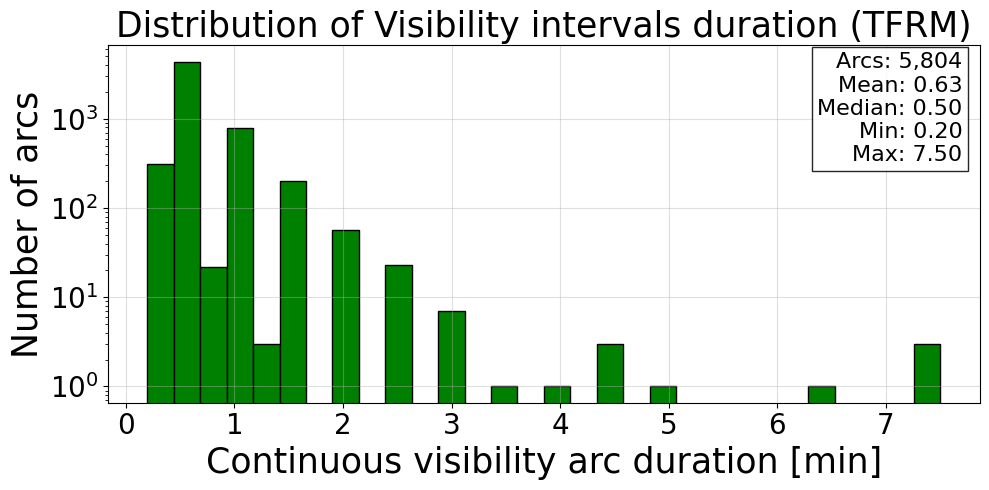

In [66]:
plot_distribution_histogram(
    data=arcs_photsat,
    column="ArcDuration_min",
    bins=30,
    logy=True,
    min_value=0,
    max_value=None,
    xlabel="Continuous visibility arc duration [min]",
    ylabel="Number of arcs",
    title="Distribution of Visibility intervals duration (TFRM)",
    stats_label="Arcs",
)

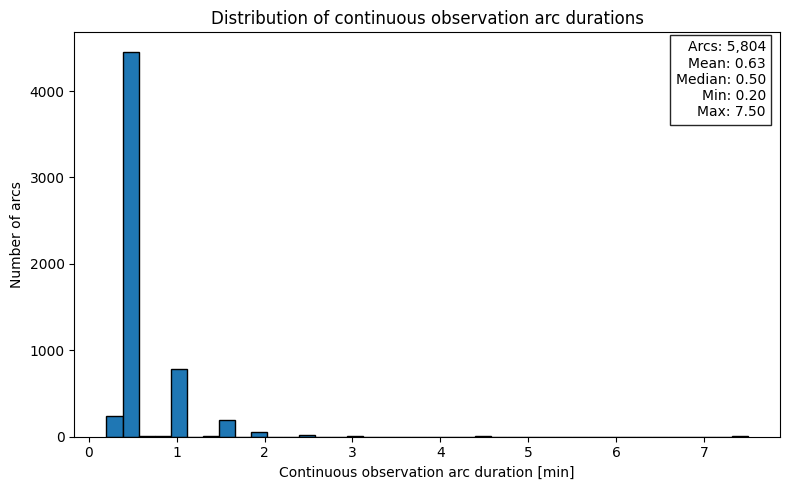

In [45]:
plot_distribution_histogram(
    data=arcs_photsat,
    column="ArcDuration_min",
    bins=40,
    min_value=0,
    xlabel="Continuous observation arc duration [min]",
    ylabel="Number of arcs",
    title="Distribution of continuous observation arc durations",
    stats_label="Arcs",
)

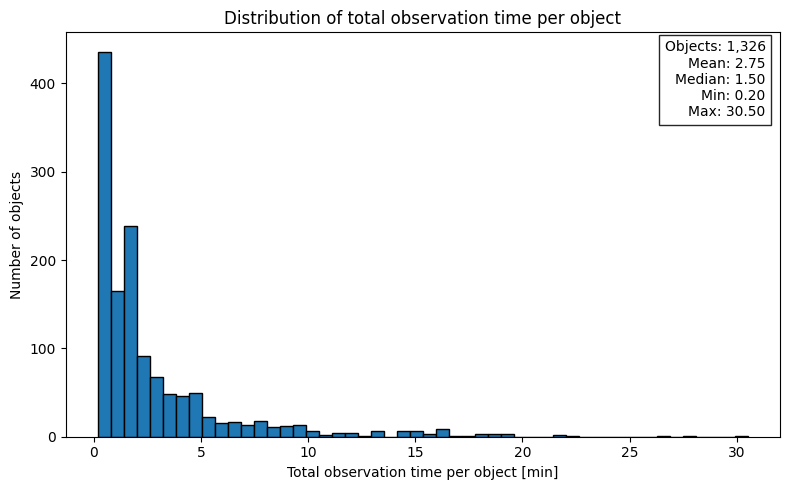

In [46]:
plot_distribution_histogram(
    data=object_arc_stats,
    column="TotalObservationTime_min",
    bins=50,
    min_value=0,
    max_value=None,
    xlabel="Total observation time per object [min]",
    ylabel="Number of objects",
    title="Distribution of total observation time per object",
    stats_label="Objects",
)

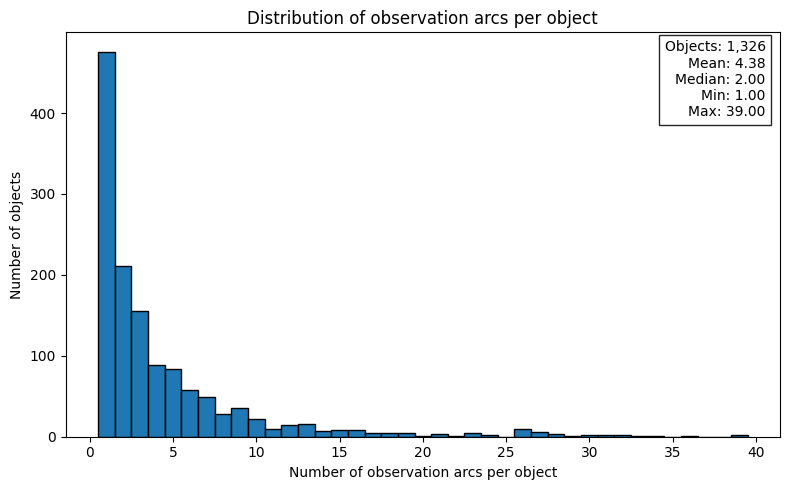

In [47]:
max_arcs = int(
    object_arc_stats["NumberOfArcs"].max()
)

arc_bins = np.arange(
    0.5,
    max_arcs + 1.5,
    1,
)

plot_distribution_histogram(
    data=object_arc_stats,
    column="NumberOfArcs",
    bins=arc_bins,
    min_value=1,
    max_value=None,
    xlabel="Number of observation arcs per object",
    ylabel="Number of objects",
    title="Distribution of observation arcs per object",
    stats_label="Objects",
)

### Statistics on arc duration and obervation time

In [49]:
from pathlib import Path
import pandas as pd


def read_visibilities(filename):
    
    #Read the SSDSIM SurveyVisibilities.dat format used in this work.

    #Each visibility entry contains:
    #start time, stop time, sensor ID, carrier ID,
    #object identifier and mean angular accuracy.
    
    rows = []

    with Path(filename).open(errors="ignore") as file:
        for line in file:
            line = line.strip()

            if (
                not line
                or line.startswith(
                    (
                        "FileName",
                        "FileStartTime",
                        "FileStopTime",
                        "VisibList",
                        "endlist",
                    )
                )
            ):
                continue

            parts = line.split()

            if len(parts) != 6:
                continue

            try:
                start = pd.to_datetime(
                    parts[0],
                    format="%Y/%m/%d-%H:%M:%S.%f",
                )

                stop = pd.to_datetime(
                    parts[1],
                    format="%Y/%m/%d-%H:%M:%S.%f",
                )

            except ValueError:
                continue

            rows.append(
                {
                    "StartTime": start,
                    "StopTime": stop,
                    "SensorID": parts[2],
                    "CarrierID": parts[3],
                    "ObjectID": parts[4],
                    "MeanAccuracy": pd.to_numeric(
                        parts[5],
                        errors="coerce",
                    ),
                }
            )

    vis = pd.DataFrame(rows)

    if vis.empty:
        raise ValueError(
            f"No visibility entries could be read from {filename}."
        )

    vis["ArcDuration_s"] = (
        vis["StopTime"] - vis["StartTime"]
    ).dt.total_seconds()

    vis["ArcDuration_min"] = vis["ArcDuration_s"] / 60.0

    vis = vis[vis["ArcDuration_s"] > 0].copy()

    return vis

vis_photsat = read_visibilities("visibilities_TFRM_SSDSIM.dat")

print("Visibility entries:", len(vis_photsat))
print("Unique objects:", vis_photsat["ObjectID"].nunique())

Visibility entries: 7420
Unique objects: 1326


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def merge_continuous_visibility_arcs(
    vis,
    max_gap_seconds=1.0,
):
    
    #Merge consecutive or overlapping visibility intervals belonging to the same object.

    #Two intervals are considered part of the same continuous arc when the gap between them is smaller than or equal to max_gap_seconds.
    
    required_columns = {
        "ObjectID",
        "StartTime",
        "StopTime",
    }

    missing = required_columns - set(vis.columns)

    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    data = vis.copy()

    data["StartTime"] = pd.to_datetime(
        data["StartTime"],
        errors="coerce",
    )

    data["StopTime"] = pd.to_datetime(
        data["StopTime"],
        errors="coerce",
    )

    data = data.dropna(
        subset=["ObjectID", "StartTime", "StopTime"]
    )

    data = data[
        data["StopTime"] > data["StartTime"]
    ].copy()

    data = data.sort_values(
        ["ObjectID", "StartTime", "StopTime"]
    )

    merged_rows = []

    for object_id, group in data.groupby(
        "ObjectID",
        sort=False,
    ):
        group = group.sort_values("StartTime")

        current_start = None
        current_stop = None
        sensor_id = None
        carrier_id = None
        number_of_segments = 0

        for row in group.itertuples(index=False):
            start = row.StartTime
            stop = row.StopTime

            if current_start is None:
                current_start = start
                current_stop = stop
                sensor_id = getattr(row, "SensorID", np.nan)
                carrier_id = getattr(row, "CarrierID", np.nan)
                number_of_segments = 1
                continue

            gap_seconds = (
                start - current_stop
            ).total_seconds()

            if gap_seconds <= max_gap_seconds:
                # Same continuous observation arc
                current_stop = max(current_stop, stop)
                number_of_segments += 1

            else:
                merged_rows.append(
                    {
                        "ObjectID": object_id,
                        "SensorID": sensor_id,
                        "CarrierID": carrier_id,
                        "ArcStartTime": current_start,
                        "ArcStopTime": current_stop,
                        "NumberOfSegments": number_of_segments,
                    }
                )

                current_start = start
                current_stop = stop
                sensor_id = getattr(row, "SensorID", np.nan)
                carrier_id = getattr(row, "CarrierID", np.nan)
                number_of_segments = 1

        # Store final arc of each object
        if current_start is not None:
            merged_rows.append(
                {
                    "ObjectID": object_id,
                    "SensorID": sensor_id,
                    "CarrierID": carrier_id,
                    "ArcStartTime": current_start,
                    "ArcStopTime": current_stop,
                    "NumberOfSegments": number_of_segments,
                }
            )

    arcs = pd.DataFrame(merged_rows)

    arcs["ArcDuration_s"] = (
        arcs["ArcStopTime"] - arcs["ArcStartTime"]
    ).dt.total_seconds()

    arcs["ArcDuration_min"] = (
        arcs["ArcDuration_s"] / 60.0
    )

    return arcs

arcs_photsat = merge_continuous_visibility_arcs(
    vis_photsat,
    max_gap_seconds=1.0,
)

print("Continuous arcs:", len(arcs_photsat))

Continuous arcs: 5804


In [51]:
def calculate_observation_statistics_per_object(arcs):
    
    #Calculate observation statistics for every object.
    
    stats = (
        arcs
        .sort_values(["ObjectID", "ArcStartTime"])
        .groupby("ObjectID")
        .agg(
            NumberOfArcs=("ObjectID", "size"),
            TotalObservationTime_min=("ArcDuration_min", "sum"),
            MeanArcDuration_min=("ArcDuration_min", "mean"),
            MedianArcDuration_min=("ArcDuration_min", "median"),
            MinArcDuration_min=("ArcDuration_min", "min"),
            MaxArcDuration_min=("ArcDuration_min", "max"),
            FirstObservation=("ArcStartTime", "min"),
            LastObservation=("ArcStopTime", "max"),
        )
        .reset_index()
    )

    stats["ObservationSpan_h"] = (
        stats["LastObservation"]
        - stats["FirstObservation"]
    ).dt.total_seconds() / 3600.0

    return stats

In [52]:
object_arc_stats = (
    calculate_observation_statistics_per_object(
        arcs_photsat
    )
)

print(object_arc_stats.head())
print()
print(
    object_arc_stats[
        [
            "NumberOfArcs",
            "TotalObservationTime_min",
            "MeanArcDuration_min",
            "MaxArcDuration_min",
            "ObservationSpan_h",
        ]
    ].describe()
)

  ObjectID  NumberOfArcs  TotalObservationTime_min  MeanArcDuration_min  \
0   00001C             4                  1.999950             0.499988   
1   00003A             5                  2.999917             0.599983   
2   00007B             2                  1.285883             0.642942   
3   00011B            36                 21.999433             0.611095   
4   00012A             5                  3.499917             0.699983   

   MedianArcDuration_min  MinArcDuration_min  MaxArcDuration_min  \
0               0.499983            0.499983            0.500000   
1               0.499983            0.499983            0.999983   
2               0.642942            0.500000            0.785883   
3               0.499983            0.499983            1.499983   
4               0.499983            0.499983            0.999983   

         FirstObservation         LastObservation  ObservationSpan_h  
0 2025-06-21 01:29:30.000 2025-06-22 01:51:47.000          24.371389 

In [53]:
def plot_distribution_histogram(
    data,
    column,
    bins=50,
    min_value=None,
    max_value=None,
    logy=False,
    xlabel=None,
    ylabel="Number of entries",
    title=None,
    stats_label="Entries",
):
    
    #Plot a histogram with optional minimum and maximum filters.
    
    values = pd.to_numeric(
        data[column],
        errors="coerce",
    ).dropna()

    original_count = len(values)

    if min_value is not None:
        values = values[values >= min_value]

    if max_value is not None:
        values = values[values <= max_value]

    if values.empty:
        raise ValueError(
            "No data remain after applying the filters."
        )

    plt.figure(figsize=(8, 5))

    plt.hist(
        values,
        bins=bins,
        edgecolor="black",
    )

    if logy:
        plt.yscale("log")

    plt.xlabel(
        xlabel if xlabel is not None else column
    )
    plt.ylabel(ylabel)

    if title is not None:
        plt.title(title)

    stats_text = (
        f"{stats_label}: {len(values):,}\n"
        f"Mean: {values.mean():.2f}\n"
        f"Median: {values.median():.2f}\n"
        f"Min: {values.min():.2f}\n"
        f"Max: {values.max():.2f}"
    )

    if len(values) != original_count:
        stats_text += (
            f"\nFiltered out: "
            f"{original_count - len(values):,}"
        )

    plt.text(
        0.98,
        0.98,
        stats_text,
        transform=plt.gca().transAxes,
        ha="right",
        va="top",
        bbox={
            "facecolor": "white",
            "alpha": 0.85,
        },
    )

    plt.tight_layout()
    plt.show()

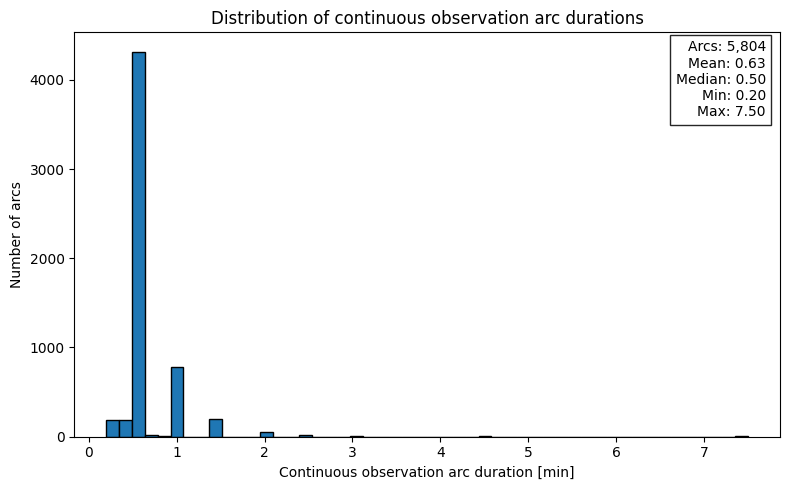

In [54]:
plot_distribution_histogram(
    data=arcs_photsat,
    column="ArcDuration_min",
    bins=50,
    min_value=0,
    max_value=None,
    xlabel="Continuous observation arc duration [min]",
    ylabel="Number of arcs",
    title="Distribution of continuous observation arc durations",
    stats_label="Arcs",
)

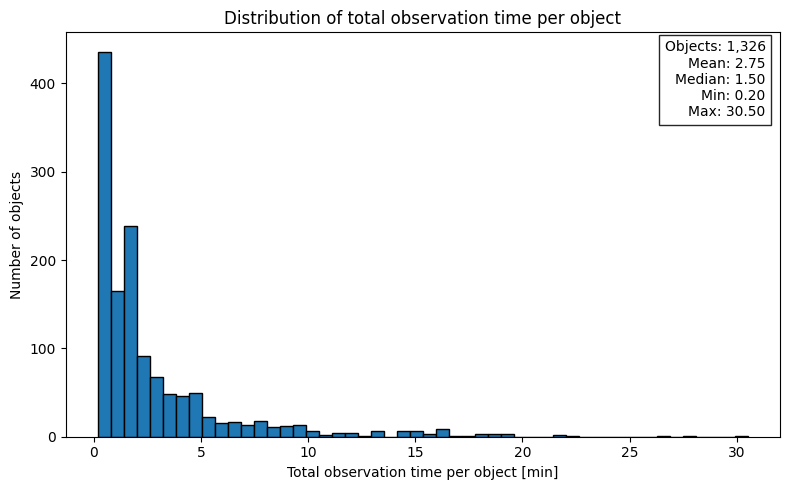

In [55]:
plot_distribution_histogram(
    data=object_arc_stats,
    column="TotalObservationTime_min",
    bins=50,
    min_value=0,
    max_value=None,
    xlabel="Total observation time per object [min]",
    ylabel="Number of objects",
    title="Distribution of total observation time per object",
    stats_label="Objects",
)

In [58]:
import re

def cospar_to_short(cospar_id):
    
    #Convert a COSPAR identifier such as 1998-067A into the short form used in visibilities files: 98067A.

    if pd.isna(cospar_id):
        return np.nan

    value = str(cospar_id).strip().upper()

    # Already in short format
    if "-" not in value:
        return value

    match = re.fullmatch(
        r"(\d{4})-(\d{3})([A-Z0-9]+)",
        value,
    )

    if match is None:
        return np.nan

    year, launch_number, piece = match.groups()

    return f"{year[-2:]}{launch_number}{piece}"


# Relate each short COSPAR identifier to its orbital class
object_orbit_classes = (
    df_all[
        ["COSPAR_ID", "OrbitClass"]
    ]
    .dropna(subset=["COSPAR_ID"])
    .drop_duplicates("COSPAR_ID")
    .copy()
)

object_orbit_classes["ObjectID"] = (
    object_orbit_classes["COSPAR_ID"]
    .apply(cospar_to_short)
)

object_orbit_classes = (
    object_orbit_classes[
        ["ObjectID", "OrbitClass"]
    ]
    .dropna(subset=["ObjectID"])
    .drop_duplicates("ObjectID")
)


# Normalise ObjectID in the visibility arcs
arcs_photsat["ObjectID"] = (
    arcs_photsat["ObjectID"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# Remove an existing OrbitClass column if the cell is rerun
arcs_photsat = arcs_photsat.drop(
    columns="OrbitClass",
    errors="ignore",
)


# Add OrbitClass to every observation arc
arcs_photsat = arcs_photsat.merge(
    object_orbit_classes,
    on="ObjectID",
    how="left",
    validate="many_to_one",
)


# Create one orbital class entry per object
object_classes = (
    arcs_photsat[
        ["ObjectID", "OrbitClass"]
    ]
    .drop_duplicates("ObjectID")
)


# Add OrbitClass to the per-object statistics
object_arc_stats = (
    object_arc_stats
    .drop(columns="OrbitClass", errors="ignore")
    .merge(
        object_classes,
        on="ObjectID",
        how="left",
        validate="one_to_one",
    )
)


print("Orbital classes assigned to the arcs:")
print(
    arcs_photsat["OrbitClass"]
    .value_counts(dropna=False)
)

print("\nOrbital classes assigned to unique objects:")
print(
    object_arc_stats["OrbitClass"]
    .value_counts(dropna=False)
)

Orbital classes assigned to the arcs:
OrbitClass
GEO       2482
GTO       1149
HEO        901
Others     815
MEO        250
LEO        207
Name: count, dtype: int64

Orbital classes assigned to unique objects:
OrbitClass
GEO       468
Others    225
GTO       186
LEO       179
HEO       146
MEO       122
Name: count, dtype: int64


In [59]:
# Statistics calculated per object
object_summary_by_class = (
    object_arc_stats
    .groupby("OrbitClass")
    .agg(
        Objects=("ObjectID", "nunique"),
        MedianNumberOfArcs=("NumberOfArcs", "median"),
        MedianTotalTime_min=("TotalObservationTime_min", "median"),
        MeanTotalTime_min=("TotalObservationTime_min", "mean"),
        MaxTotalTime_min=("TotalObservationTime_min", "max"),
    )
)


# Statistics calculated directly from the observation arcs
arc_summary_by_class = (
    arcs_photsat
    .groupby("OrbitClass")
    .agg(
        TotalArcs=("ObjectID", "size"),
        MedianArcDuration_min=("ArcDuration_min", "median"),
        MeanArcDuration_min=("ArcDuration_min", "mean"),
        MaxArcDuration_min=("ArcDuration_min", "max"),
    )
)


# Combine both summaries
summary_by_class = (
    object_summary_by_class
    .join(arc_summary_by_class)
    .round(2)
    .sort_values("Objects", ascending=False)
)

display(summary_by_class)

,Objects,MedianNumberOfArcs,MedianTotalTime_min,MeanTotalTime_min,MaxTotalTime_min,TotalArcs,MedianArcDuration_min,MeanArcDuration_min,MaxArcDuration_min
OrbitClass,,,,,,,,,
GEO,468,4.5,2.50,3.34,18.50,2482,0.50,0.63,7.50
Others,225,2.0,1.00,2.22,16.50,815,0.50,0.61,2.50
GTO,186,3.0,1.50,4.01,30.50,1149,0.50,0.65,7.50
LEO,179,1.0,0.31,0.43,11.97,207,0.32,0.38,2.50
HEO,146,2.0,1.50,4.06,28.00,901,0.50,0.66,4.50
MEO,122,2.0,1.00,1.37,8.46,250,0.50,0.67,6.46


C:\Users\trccsi\AppData\Local\Temp\ipykernel_28420\3403693638.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


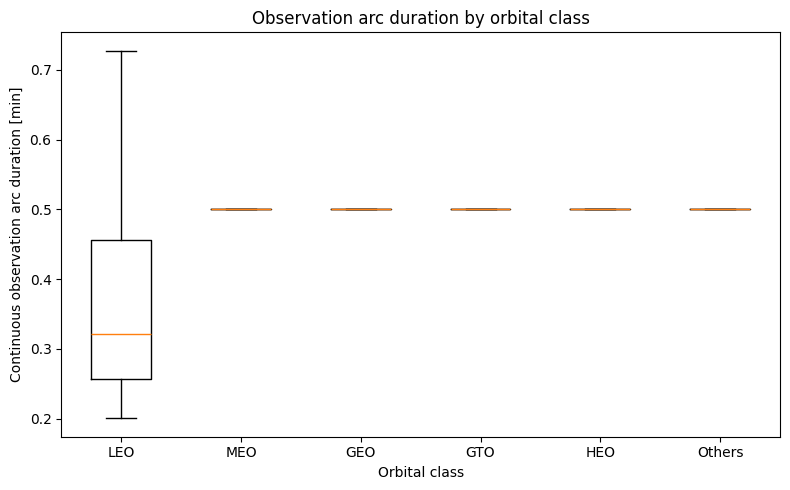

In [60]:
import matplotlib.pyplot as plt

orbit_order = ["LEO", "MEO", "GEO", "GTO", "HEO", "Others"]

data_by_class = [
    arcs_photsat.loc[
        arcs_photsat["OrbitClass"] == orbit_class,
        "ArcDuration_min",
    ].dropna()
    for orbit_class in orbit_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    data_by_class,
    labels=orbit_order,
    showfliers=False,
)

plt.xlabel("Orbital class")
plt.ylabel("Continuous observation arc duration [min]")
plt.title("Observation arc duration by orbital class")
plt.tight_layout()
plt.show()

C:\Users\trccsi\AppData\Local\Temp\ipykernel_28420\2820072196.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


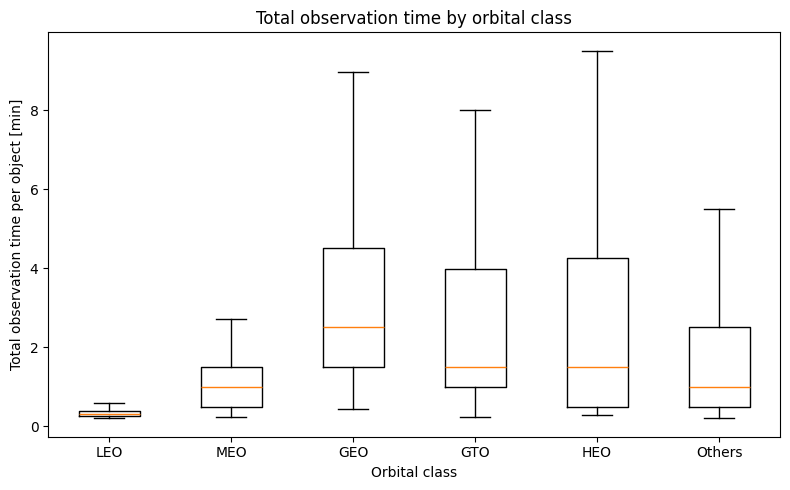

In [61]:
data_by_class = [
    object_arc_stats.loc[
        object_arc_stats["OrbitClass"] == orbit_class,
        "TotalObservationTime_min",
    ].dropna()
    for orbit_class in orbit_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    data_by_class,
    labels=orbit_order,
    showfliers=False,
)

plt.xlabel("Orbital class")
plt.ylabel("Total observation time per object [min]")
plt.title("Total observation time by orbital class")
plt.tight_layout()
plt.show()

In [62]:
def plot_histograms_by_orbit_class(
    data,
    column,
    xlabel,
    title_prefix,
    bins=40,
    min_value=None,
    max_value=None,
):

    orbit_order = [
        "LEO",
        "MEO",
        "GEO",
        "GTO",
        "HEO",
        "Others",
    ]

    for orbit in orbit_order:

        subset = data[data["OrbitClass"] == orbit]

        if subset.empty:
            continue

        plot_distribution_histogram(
            data=subset,
            column=column,
            bins=bins,
            min_value=min_value,
            max_value=max_value,
            xlabel=xlabel,
            ylabel="Number of objects" if data is object_arc_stats else "Number of arcs",
            title=f"{title_prefix} ({orbit})",
            stats_label="Objects" if data is object_arc_stats else "Arcs",
        )

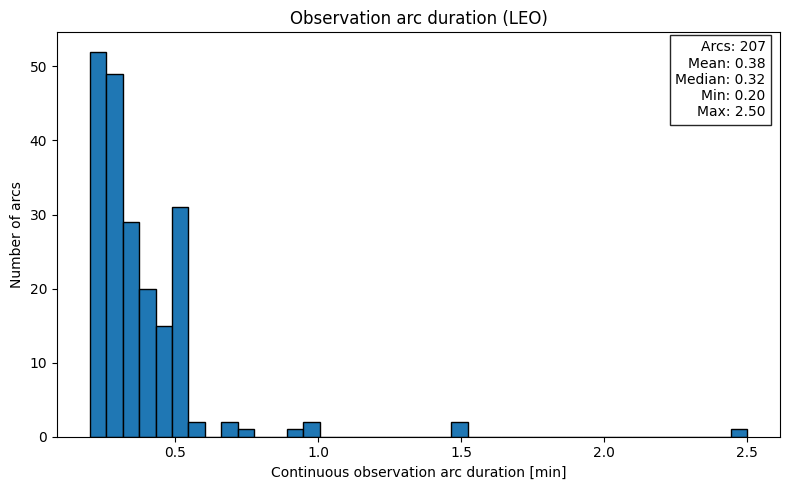

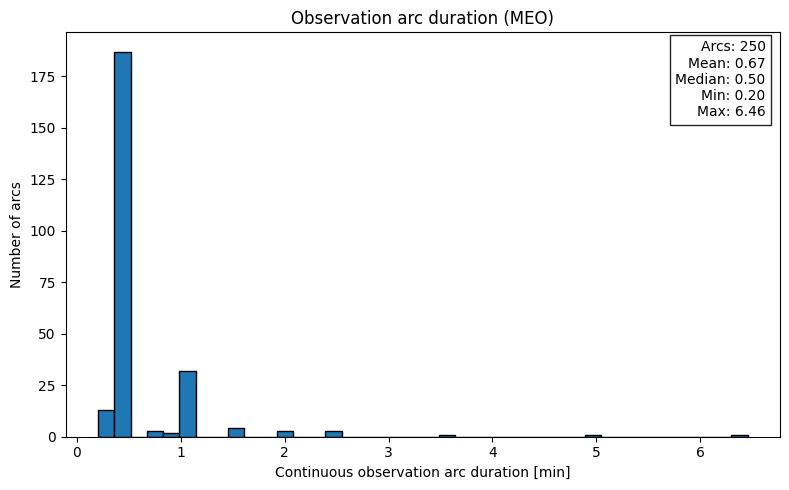

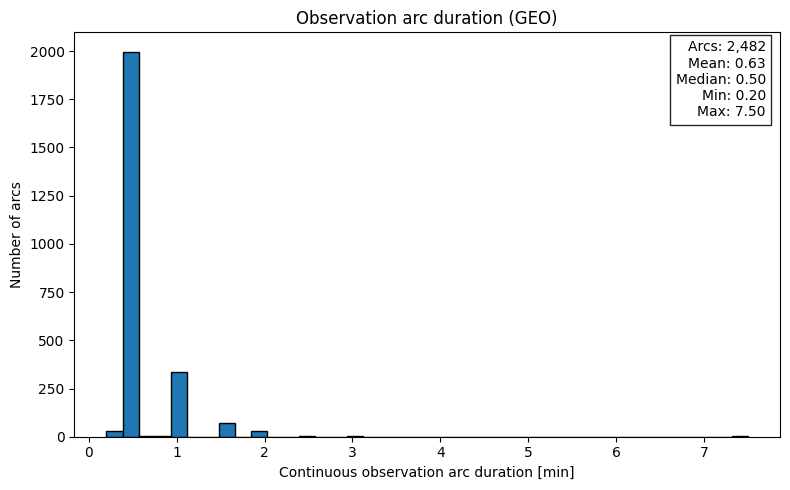

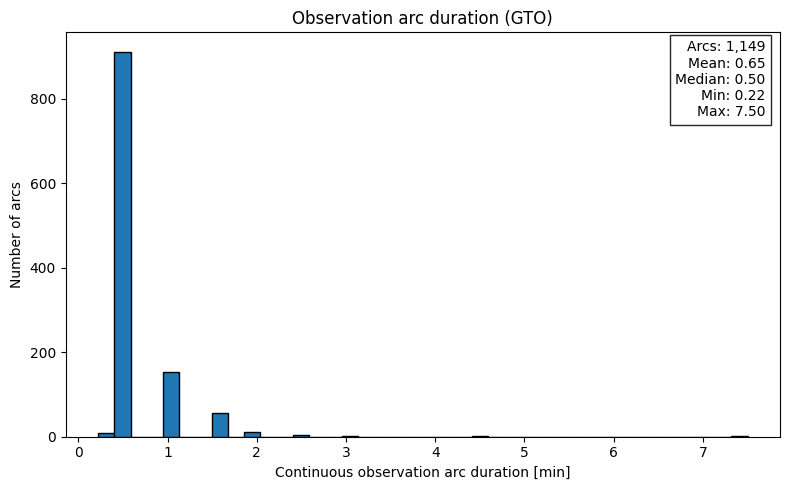

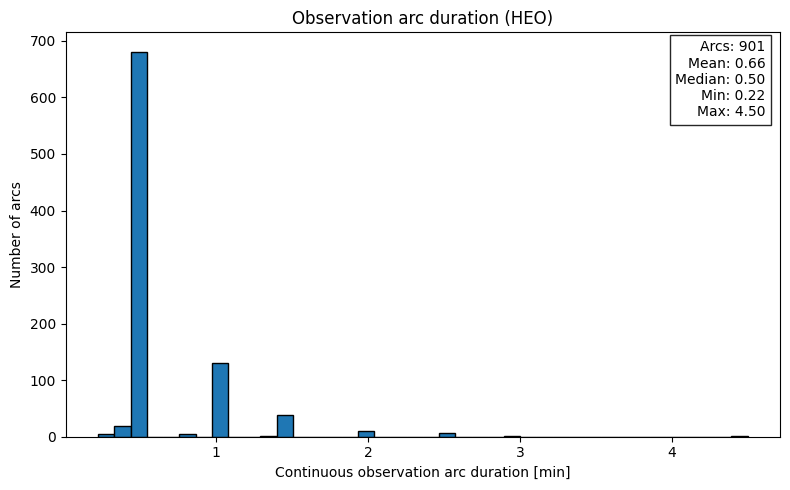

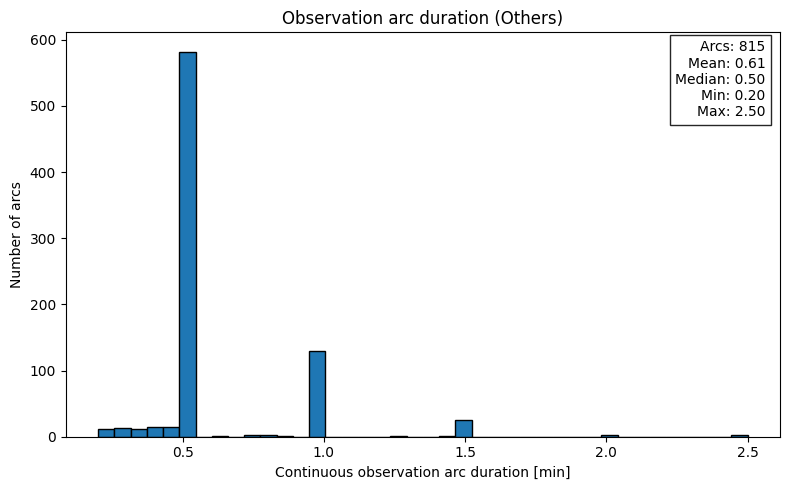

In [63]:
plot_histograms_by_orbit_class(
    data=arcs_photsat,
    column="ArcDuration_min",
    xlabel="Continuous observation arc duration [min]",
    title_prefix="Observation arc duration",
    bins=40,
)

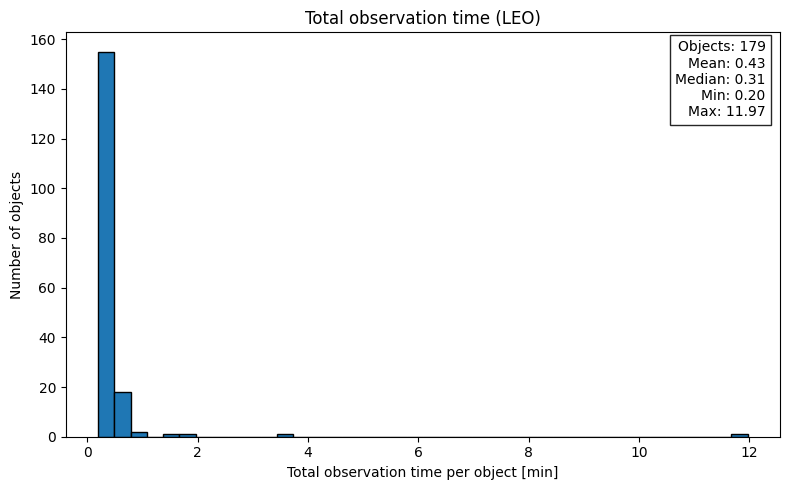

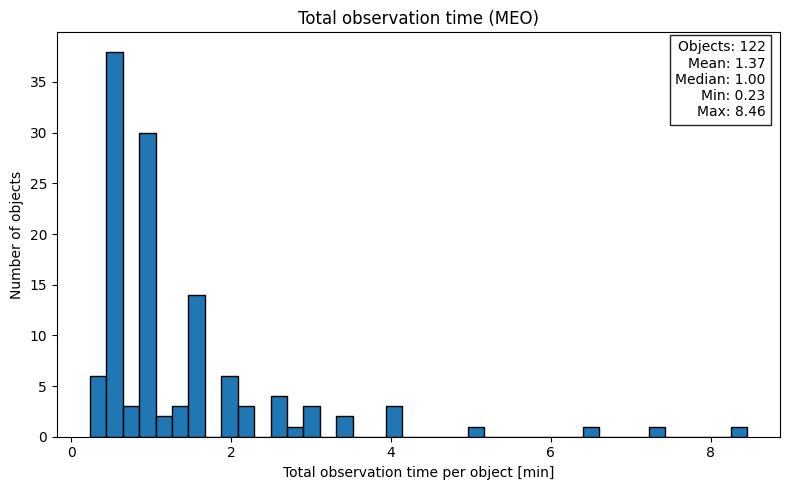

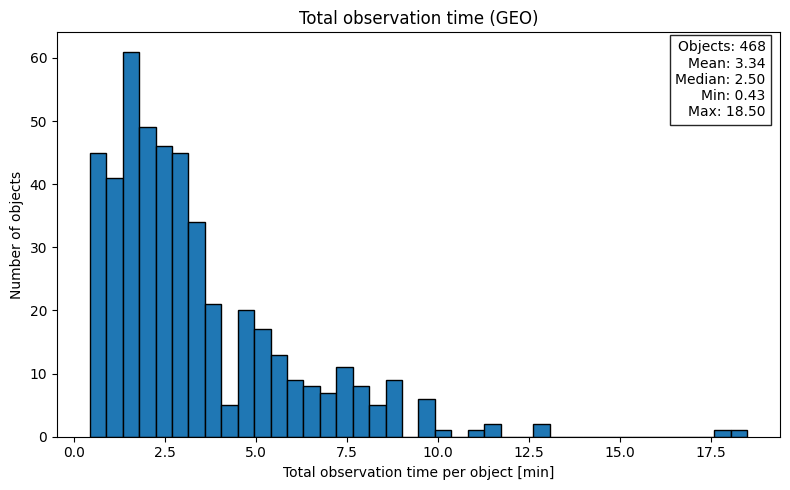

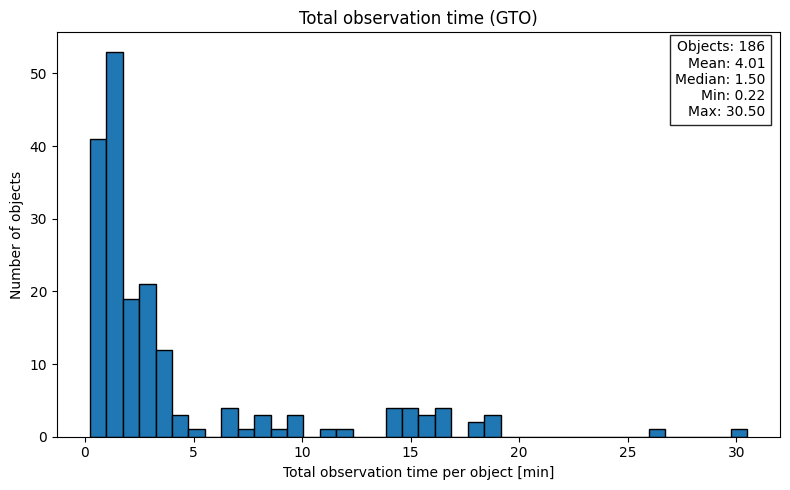

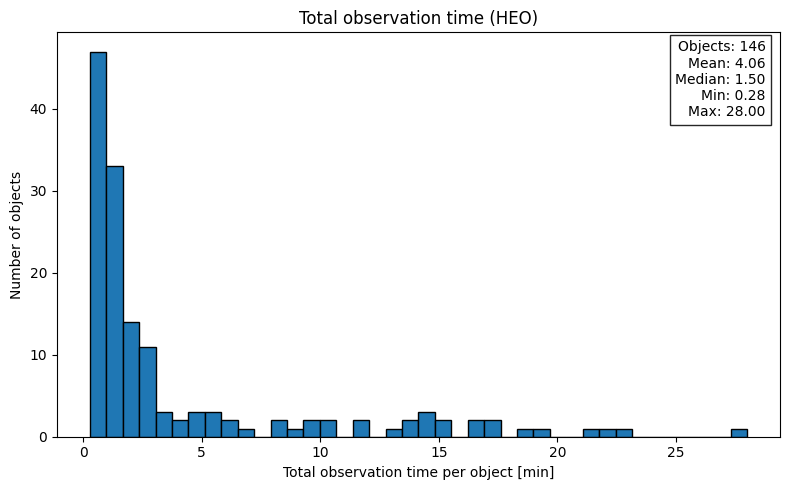

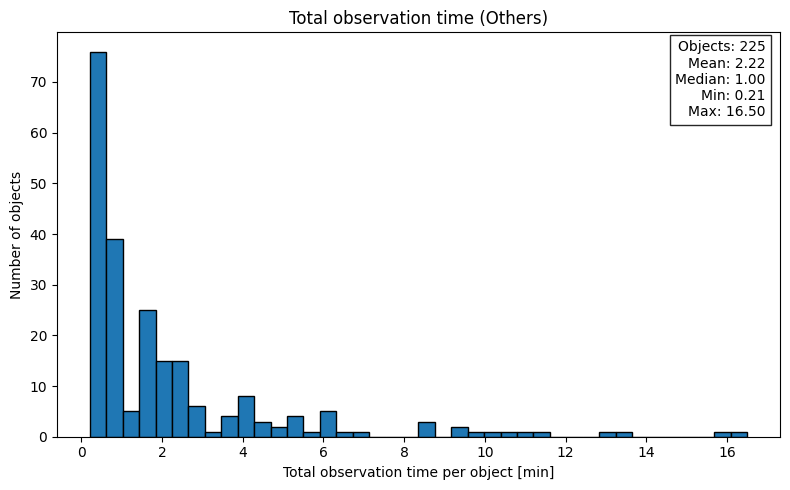

In [64]:
plot_histograms_by_orbit_class(
    data=object_arc_stats,
    column="TotalObservationTime_min",
    xlabel="Total observation time per object [min]",
    title_prefix="Total observation time",
    bins=40,
)

In [65]:
def plot_histograms_by_orbit_class(
    data,
    column,
    xlabel,
    ylabel,
    title,
    bins=25,
    min_value=None,
    max_value=None,
):

    orbit_order = [
        "LEO",
        "MEO",
        "GEO",
        "GTO",
        "HEO",
        "Others",
    ]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)

    axes = axes.flatten()

    for ax, orbit in zip(axes, orbit_order):

        subset = data[data["OrbitClass"] == orbit]

        values = subset[column].dropna()

        if min_value is not None:
            values = values[values >= min_value]

        if max_value is not None:
            values = values[values <= max_value]

        if len(values) == 0:
            ax.set_title(orbit)
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            continue

        ax.hist(
            values,
            bins=bins,
            edgecolor="black",
        )

        ax.set_title(orbit)

        stats = (
            f"N = {len(values)}\n"
            f"Mean = {values.mean():.2f}\n"
            f"Median = {values.median():.2f}"
        )

        ax.text(
            0.98,
            0.98,
            stats,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.8),
        )

    fig.suptitle(title, fontsize=15)

    fig.supxlabel(xlabel)
    fig.supylabel(ylabel)

    plt.tight_layout()
    plt.show()

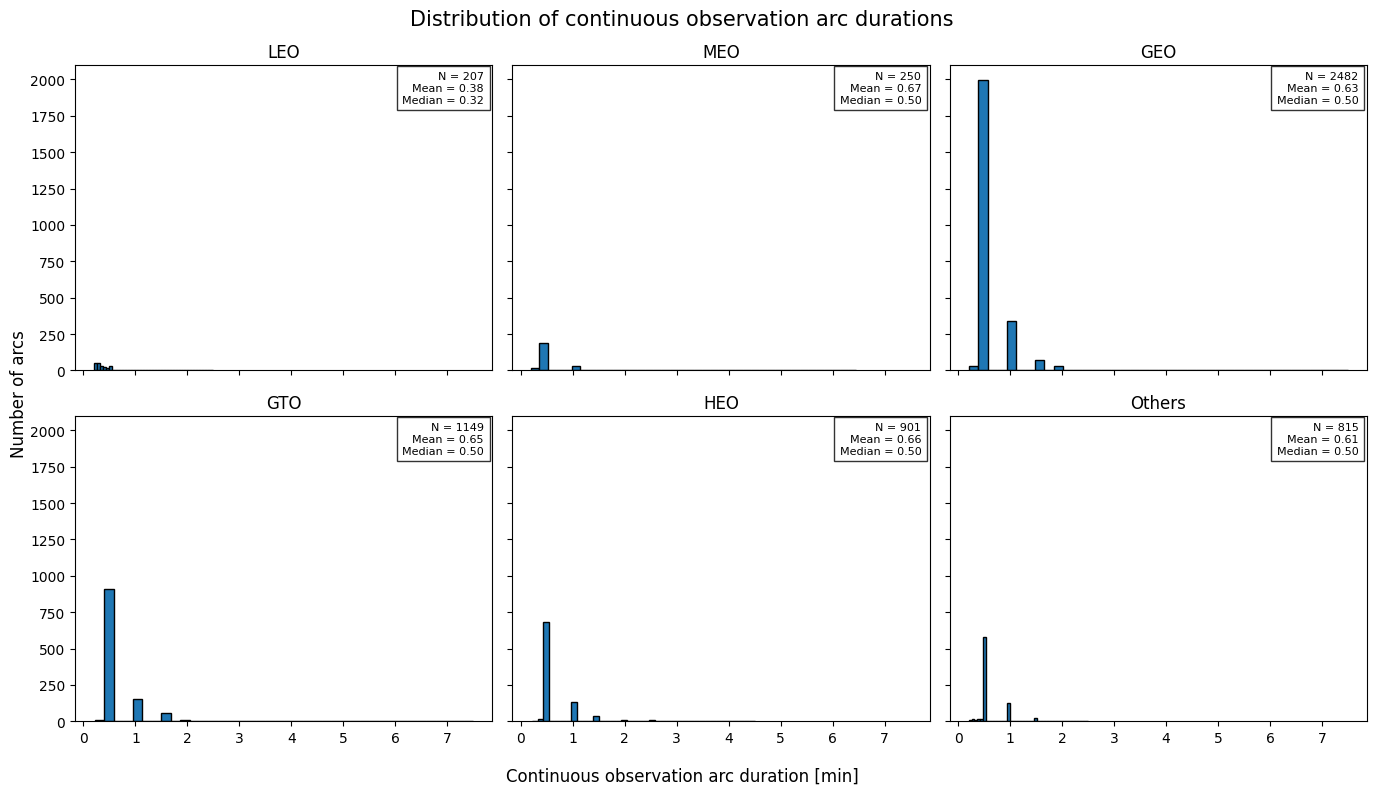

In [66]:
plot_histograms_by_orbit_class(
    data=arcs_photsat,
    column="ArcDuration_min",
    xlabel="Continuous observation arc duration [min]",
    ylabel="Number of arcs",
    title="Distribution of continuous observation arc durations",
    bins=40,
)

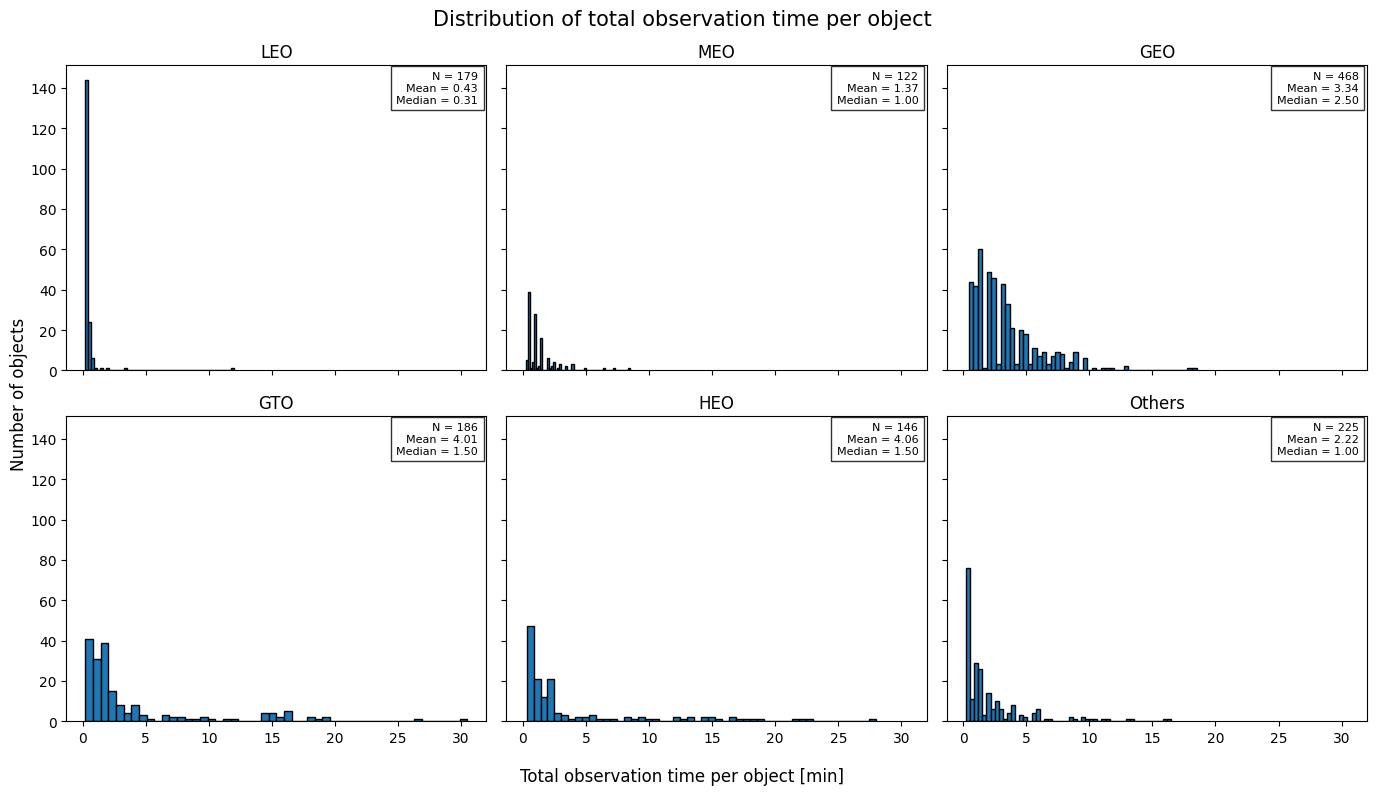

In [67]:
plot_histograms_by_orbit_class(
    data=object_arc_stats,
    column="TotalObservationTime_min",
    xlabel="Total observation time per object [min]",
    ylabel="Number of objects",
    title="Distribution of total observation time per object",
    bins=50,
)

In [34]:
def count_tle_objects(tle_file):
    with open(tle_file, "r") as f:
        return sum(
            1 for line in f
            if line.startswith("1 ")
        )


n_catalogue = count_tle_objects("catalogue.tle")

# Unique objects detected by SSDSIM
n_detected = df_all["ObjectID"].nunique()

percentage_detected = (
    n_detected / n_catalogue * 100
)

print(f"Objects in input catalogue: {n_catalogue:,}")
print(f"Unique objects detected: {n_detected:,}")
print(f"Percentage detected: {percentage_detected:.2f}%")

Objects in input catalogue: 27,555
Unique objects detected: 1,326
Percentage detected: 4.81%


In [35]:
n_catalogue = count_tle_objects("catalogue.tle")

n_detected_all = df_all["ObjectID"].nunique()
n_detected_snr3 = df_snr3["ObjectID"].nunique()
n_detected_snr6 = df_snr6["ObjectID"].nunique()

print(f"Objects in input catalogue: {n_catalogue:,}")
print()

print(
    f"SSDSIM detections: {n_detected_all:,} "
    f"({100 * n_detected_all / n_catalogue:.2f}%)"
)

print(
    f"SNR >= 3: {n_detected_snr3:,} "
    f"({100 * n_detected_snr3 / n_catalogue:.2f}%)"
)

print(
    f"SNR >= 6: {n_detected_snr6:,} "
    f"({100 * n_detected_snr6 / n_catalogue:.2f}%)"
)

Objects in input catalogue: 27,555

SSDSIM detections: 1,326 (4.81%)
SNR >= 3: 1,320 (4.79%)
SNR >= 6: 1,316 (4.78%)
